In [1]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr          # Pearson correlation coefficient
from scipy.spatial.distance import cdist  # pairwise distances between arrays
from sklearn.decomposition import PCA     # dimensionality reduction
from sklearn.manifold import TSNE         # non-linear 2D embedding
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Fix random seeds so every run gives the same results (reproducibility)
np.random.seed(42)
RNG = np.random.default_rng(42)

print("="*68)
print("  PolyVAE — GENERATIVE CONDUCTIVE POLYMER DESIGN")
print("="*68)

  PolyVAE — GENERATIVE CONDUCTIVE POLYMER DESIGN


In [2]:
# GLOBAL CONSTANTS

# WHAT THIS DOES:
#   Defines the three most important numbers in the whole project.
#   Changing any of these changes the entire pipeline.
#
#   N_POLY  = how many polymer molecules are in our training dataset
#   FP_DIM  = how many bits in our Morgan fingerprint
#             (real research uses 2048; we use 64 for speed)
#   LAT_DIM = the number of dimensions in the VAE's latent space
#             Think of this as how many "knobs" describe a polymer.
#             L=8 means every polymer is represented by 8 numbers.
N_POLY   = 500    # training dataset size
FP_DIM   = 64     # Morgan fingerprint bits (real pipeline: 2048)
LAT_DIM  = 8      # VAE latent dimension — the "chemical design space"


In [3]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr          # Pearson correlation coefficient
from scipy.spatial.distance import cdist  # pairwise distances between arrays
from sklearn.decomposition import PCA     # dimensionality reduction
from sklearn.manifold import TSNE         # non-linear 2D embedding
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# Fix random seeds so every run gives the same results (reproducibility)
np.random.seed(42)
RNG = np.random.default_rng(42)

print("="*68)
print("  PolyVAE — GENERATIVE CONDUCTIVE POLYMER DESIGN")
print("="*68)

FAMILIES = {
    # name : {pi_conj, backbone_rigidity, doping_affinity, base_conductivity}
    'PEDOT':         {'pi_conj':0.98,'rigid':0.88,'dop_aff':0.70,'base':5.1},
    'Polythiophene': {'pi_conj':0.95,'rigid':0.80,'dop_aff':0.75,'base':4.2},
    'Polypyrrole':   {'pi_conj':0.88,'rigid':0.72,'dop_aff':0.85,'base':3.8},
    'Polyaniline':   {'pi_conj':0.82,'rigid':0.65,'dop_aff':0.90,'base':3.5},
    'Polyfluorene':  {'pi_conj':0.78,'rigid':0.92,'dop_aff':0.45,'base':1.8},
    'Polycarbazole': {'pi_conj':0.72,'rigid':0.88,'dop_aff':0.38,'base':1.2},
}
FAM_NAMES  = list(FAMILIES.keys())

# Color assigned to each family — used consistently across all figures
FAM_COLORS = {
    'PEDOT':         '#C62828',   # dark red
    'Polythiophene': '#00695C',   # dark teal
    'Polypyrrole':   '#1565C0',   # dark blue
    'Polyaniline':   '#E65100',   # dark orange
    'Polyfluorene':  '#4527A0',   # dark violet
    'Polycarbazole': '#2E7D32',   # dark green
}

def make_dataset(n=500, seed=42):
    """
    Generate n synthetic polymer molecules.
    Returns a pandas DataFrame with 13 physical features + 64 fingerprint
    bits + log_sigma (the target conductivity).
    """
    rng   = np.random.default_rng(seed)
    # Sample polymer families with realistic proportions
    probs = [0.15, 0.22, 0.18, 0.20, 0.15, 0.10]   # must sum to 1.0
    fams  = rng.choice(FAM_NAMES, n, p=probs)        # assign a family to each molecule

    rows = []
    for i, fam in enumerate(fams):
        fp = FAMILIES[fam]   # get that family's baseline properties

        # ── PHYSICOCHEMICAL DESCRIPTORS ──────────────────────────────────────
        # Each feature = family baseline + small random noise (real variation)
        # np.clip(value, min, max) = keep inside physically sensible bounds

        pi  = np.clip(fp['pi_conj'] + rng.normal(0, 0.06), 0.3, 1.0)
        # π-conjugation: how extended is the conjugated backbone?
        # Range 0.3–1.0 (0=no conjugation, 1=perfect conjugation)

        rig = np.clip(fp['rigid']   + rng.normal(0, 0.07), 0.3, 1.0)
        # Backbone rigidity: how stiff is the polymer chain?

        da  = np.clip(fp['dop_aff'] + rng.normal(0, 0.07), 0.1, 1.0)
        # Doping affinity: how easily can we add charge carriers (dopants)?

        clen = rng.integers(8, 80)              # chain length in repeat units
        mw   = clen * rng.uniform(80, 200)      # molecular weight = units × mass/unit

        gap = np.clip(3.5 - 2.8*pi + rng.normal(0, 0.15), 0.2, 3.5)
        # HOMO-LUMO gap (eV): higher π-conjugation → smaller gap
        # Smaller gap = easier to dope = better conductor

        ip  = np.clip(4.2 + 1.5*(1-da) + rng.normal(0, 0.12), 4.0, 6.5)
        # Ionization potential: energy to remove an electron from the polymer

        ea  = np.clip(ip - gap - rng.normal(0.2, 0.08), 0.5, 4.0)
        # Electron affinity: ip - gap = approximate relationship

        scp = rng.uniform(0.1, 0.9)
        # Side-chain polarity: do the side chains attract/repel solvents?

        cry = np.clip(rig*0.7 + rng.normal(0, 0.10), 0.1, 0.95)
        # Crystallinity: rigid backbone → more ordered crystal structure

        mob = np.clip(pi**2 * 0.8 + rng.normal(0, 0.05), 0.01, 1.0)
        # Charge mobility: higher π-conjugation → faster charge hopping
        # Squared because mobility scales non-linearly with conjugation

        dis = np.clip(1 - cry + rng.normal(0, 0.08), 0.05, 0.90)
        # Disorder: crystallinity and disorder are roughly inverse

        dop = rng.uniform(0.05, 0.40)
        # Dopant concentration: molar fraction of dopant added

        # ── MORGAN FINGERPRINT SIMULATION ────────────────────────────────────
        # Real Morgan fingerprints: circular algorithm on molecular graph
        # We simulate: family-specific signature bits + conjugation bits + noise
        bits = np.zeros(FP_DIM)

        # Each family has a "signature" — a block of bits always set to 1
        fam_idx = FAM_NAMES.index(fam)
        s = (fam_idx * 10) % FP_DIM         # start position in the bit array
        bits[s:min(s+8, FP_DIM)] = 1.0     # set 8 signature bits

        # More conjugated molecules have more aromatic fragments → more bits set
        cbits = rng.choice(FP_DIM, int(pi*15), replace=False)
        bits[cbits] = 1.0

        # Random flips with 8% probability = structural variation between molecules
        bits = np.abs(bits - (rng.random(FP_DIM) < 0.08)).clip(0, 1)

        # ── CONDUCTIVITY TARGET ───────────────────────────────────────────────
        # This is the Marcus transport model + additive noise
        lc = (fp['base']
              + 2.8*pi          # π-conjugation is the strongest driver
              + 1.5*da          # doping affinity
              + 1.8*dop         # dopant concentration
              + 1.2*mob         # charge carrier mobility
              - 0.9*dis         # disorder hurts transport
              - 0.4*gap         # large gap = activation barrier
              + 0.3*cry         # crystallinity helps slightly
              - 0.2*scp         # bulky side chains hinder π-stacking
              + rng.normal(0, 0.35))   # synthesis and measurement noise

        # Pack everything into one row dictionary
        row = dict(
            family=fam,
            pi_conj=round(pi,4), backbone_rig=round(rig,4),
            dop_affinity=round(da,4), chain_len=int(clen),
            mol_wt=round(mw,1), homo_lumo_gap=round(gap,4),
            ioniz_pot=round(ip,4), electron_aff=round(ea,4),
            sidechain_pol=round(scp,4), crystallinity=round(cry,4),
            charge_mob=round(mob,4), disorder=round(dis,4),
            dopant_conc=round(dop,4), log_sigma=round(lc,4)
        )
        # Add all 64 fingerprint bits as separate columns fp000, fp001, ...
        for b in range(FP_DIM):
            row[f'fp{b:03d}'] = int(bits[b])
        rows.append(row)

    return pd.DataFrame(rows)


print("\n[Stage 1] Generating polymer dataset…")
df = make_dataset(N_POLY)
df.to_csv('/tmp/polymer_dataset.csv', index=False)   # save to disk
print(f"  Polymers: {len(df)}  Families: {df['family'].nunique()}")
print(f"  log(σ) range: {df['log_sigma'].min():.2f} → {df['log_sigma'].max():.2f} log(S/cm)")

  PolyVAE — GENERATIVE CONDUCTIVE POLYMER DESIGN

[Stage 1] Generating polymer dataset…
  Polymers: 500  Families: 6
  log(σ) range: 2.65 → 10.73 log(S/cm)


In [4]:
# STAGE 2 — FEATURE MATRIX CONSTRUCTION
# WHAT THIS DOES:
#   Builds the numerical input matrix X that goes into the VAE.
#
#   We have TWO types of features:
#     PHYS_COLS (13 features) → continuous numbers like 0.82, 3.14, 150
#     FP_COLS   (64 features) → binary bits, already 0 or 1
#
#   PROBLEM: The physical features have wildly different scales.
#     mol_wt goes from 0 to 10,000
#     pi_conj goes from 0.3 to 1.0
#   If we feed these directly into the VAE, mol_wt will dominate
#   because its numbers are 10,000× larger.
#
#   SOLUTION: StandardScaler
#     For each physical feature: subtract mean, divide by std
#     After scaling: every feature has mean=0 and std=1
#     Now all features compete fairly in the neural network.
#   FINAL INPUT:
#     X_vae = [scaled physical features | binary fingerprints]
#     Shape: (500, 77) = 500 polymers × (13 + 64) features

# Column name lists
PHYS_COLS = ['pi_conj','backbone_rig','dop_affinity','chain_len','mol_wt',
             'homo_lumo_gap','ioniz_pot','electron_aff','sidechain_pol',
             'crystallinity','charge_mob','disorder','dopant_conc']
FP_COLS   = [f'fp{b:03d}' for b in range(FP_DIM)]

X_phys = df[PHYS_COLS].values.astype(np.float32)   # shape (500, 13) — physical descriptors
X_fp   = df[FP_COLS].values.astype(np.float32)     # shape (500, 64) — fingerprint bits
y      = df['log_sigma'].values.astype(np.float32)  # shape (500,)   — target conductivity

# StandardScaler: learns mean and std from the 500 polymers, then applies them
sc   = StandardScaler()
X_sc = sc.fit_transform(X_phys)   # scaled physical features, shape (500, 13)
# fit_transform = fit (learn statistics) + transform (apply) in one step

# Concatenate scaled physical + binary fingerprints horizontally
X_vae  = np.hstack([X_sc, X_fp]).astype(np.float32)
# np.hstack = stack arrays side by side: (500,13) + (500,64) → (500,77)

IN_DIM = X_vae.shape[1]   # = 77: the number of input features to the VAE
print(f"\n[Stage 2] Feature matrix: {X_vae.shape}  "
      f"({len(PHYS_COLS)} phys + {FP_DIM} fp bits)")

# Human-readable labels for axis tick marks in figures
FEAT_LBL = {
    'pi_conj':'π-Conjugation',   'backbone_rig':'Backbone Rigidity',
    'dop_affinity':'Doping Affinity', 'chain_len':'Chain Length',
    'mol_wt':'Mol. Weight',       'homo_lumo_gap':'HOMO-LUMO Gap',
    'ioniz_pot':'Ionization Pot.','electron_aff':'Electron Affinity',
    'sidechain_pol':'Side-Chain Polarity','crystallinity':'Crystallinity',
    'charge_mob':'Charge Mobility','disorder':'Disorder Param.',
    'dopant_conc':'Dopant Conc.'
}



[Stage 2] Feature matrix: (500, 77)  (13 phys + 64 fp bits)


In [5]:
# STAGE 3 — VARIATIONAL AUTOENCODER (VAE) IN  NUMPY
# WHAT THIS DOES:
#   Trains a VAE — a generative neural network — from scratch using only NumPy.

print("\n[Stage 3] VAE training (NumPy)…")

# ── Activation functions ──────────────────────────────────────────────────────
def relu(x):
    """ReLU: max(0, x) — sets negative values to 0, keeps positive values."""
    return np.maximum(0.0, x)

def drelu(x):
    """Derivative of ReLU: 1 if x > 0, else 0. Used in backpropagation."""
    return (x > 0).astype(np.float32)


class PolyVAE:
    """
    Variational Autoencoder implemented in pure NumPy.
    Every weight matrix, every gradient, every Adam update is explicit.
    """

    def __init__(self, in_dim, h=(128, 64), L=8, beta=1.0, lr=8e-4):
        """
        Initialise all weight matrices.

        in_dim = input dimension (77 = 13 phys + 64 fp)
        h      = hidden layer sizes (128 then 64)
        L      = latent dimension (8)
        beta   = KL weight (1.0 = standard VAE)
        lr     = learning rate for Adam (0.0008)
        """
        self.D, self.L, self.beta, self.lr = in_dim, L, beta, lr
        h1, h2 = h   # h1=128 (first hidden), h2=64 (second hidden)

        def W(fan_in, fan_out):
            """
            He initialisation: σ = √(2/fan_in)
            Keeps variance of activations stable through deep layers.
            Without this, activations explode or vanish after a few layers.
            """
            return RNG.normal(0, np.sqrt(2/fan_in),
                              (fan_in, fan_out)).astype(np.float32)

        def b(n):
            """Bias vector: initialised to zero."""
            return np.zeros(n, np.float32)

        # ── ENCODER WEIGHTS ────────────────────────────────────────────────
        # Layer 1: Input → Hidden1
        self.We1, self.be1 = W(in_dim, h1), b(h1)   # (77,128) and (128,)
        # Layer 2: Hidden1 → Hidden2
        self.We2, self.be2 = W(h1, h2),    b(h2)    # (128,64) and (64,)
        # Output heads: Hidden2 → μ and Hidden2 → logvar
        self.Wmu,  self.bmu  = W(h2, L),   b(L)     # (64,8) and (8,)
        self.Wlv,  self.blv  = W(h2, L),   b(L)     # (64,8) and (8,)

        # ── DECODER WEIGHTS ────────────────────────────────────────────────
        # Mirror of encoder (symmetric architecture)
        self.Wd1, self.bd1 = W(L,  h2),    b(h2)    # (8,64) and (64,)
        self.Wd2, self.bd2 = W(h2, h1),    b(h1)    # (64,128) and (128,)
        self.Wo,  self.bo  = W(h1, in_dim),b(in_dim) # (128,77) and (77,)

        # ── ADAM OPTIMISER STATE ───────────────────────────────────────────
        # Adam keeps a running "memory" of past gradients per parameter.
        # _m = first moment (mean of gradients) — exponential moving average
        # _v = second moment (variance) — exponential moving average of squared gradients
        pnames = ['We1','be1','We2','be2','Wmu','bmu','Wlv','blv',
                  'Wd1','bd1','Wd2','bd2','Wo','bo']
        self._m = {p: np.zeros_like(getattr(self, p)) for p in pnames}
        self._v = {p: np.zeros_like(getattr(self, p)) for p in pnames}
        self._t = 0             # timestep counter for bias correction
        self._pnames = pnames

    # ── FORWARD PASS — ENCODER ───────────────────────────────────────────────
    def _encode(self, X):
        """
        Encoder: X (n, D) → μ (n, L) and logvar (n, L)

        Each layer: activation = ReLU(input @ weight + bias)
        @ = matrix multiplication
        """
        a1 = relu(X  @ self.We1 + self.be1)   # (n,77)@(77,128) → (n,128)
        a2 = relu(a1 @ self.We2 + self.be2)   # (n,128)@(128,64) → (n,64)
        mu     = a2 @ self.Wmu + self.bmu     # (n,64)@(64,8) → (n,8) — mean
        logvar = np.clip(a2 @ self.Wlv + self.blv, -4, 4)
        # logvar = log of variance (log scale is more stable numerically)
        # np.clip(-4, 4) prevents σ from becoming 0 or infinity
        return a1, a2, mu, logvar

    # ── REPARAMETERISATION TRICK ─────────────────────────────────────────────
    def _reparam(self, mu, logvar):
        """
        Sample z = μ + ε·σ  where ε ~ N(0,I)

        Why not just sample z ~ N(μ, σ²)?
        Because sampling is not differentiable — we can't compute ∂z/∂μ.
        Fix: express z as a deterministic function of μ, σ, and ε.
        During backprop, ε is treated as a constant (external noise).
        Gradients flow through μ and σ normally.
        """
        eps   = RNG.standard_normal(mu.shape).astype(np.float32)
        sigma = np.exp(0.5 * logvar)   # σ = exp(logvar/2) = √(variance)
        z     = mu + eps * sigma       # reparameterised sample
        return z, eps, sigma           # return eps and sigma for backprop

    # ── FORWARD PASS — DECODER ───────────────────────────────────────────────
    def _decode(self, z):
        """
        Decoder: z (n, L) → x_hat (n, D)

        Takes the 8-dimensional latent code and reconstructs
        the full 77-dimensional polymer representation.
        Linear output (no activation): allows any real number output.
        """
        d1 = relu(z  @ self.Wd1 + self.bd1)   # (n,8)@(8,64) → (n,64)
        d2 = relu(d1 @ self.Wd2 + self.bd2)   # (n,64)@(64,128) → (n,128)
        xh = d2 @ self.Wo + self.bo            # (n,128)@(128,77) → (n,77)
        return d1, d2, xh

    # ── ADAM OPTIMISER UPDATE ────────────────────────────────────────────────
    def _adam(self, pname, g):
        """
        Adam update for one weight matrix.

        Standard gradient descent: θ ← θ - lr × g
        Adam:
          m ← β₁·m + (1-β₁)·g         (exponential moving average of gradient)
          v ← β₂·v + (1-β₂)·g²        (exponential moving average of gradient²)
          m_hat = m / (1-β₁ᵗ)         (bias correction for early steps)
          v_hat = v / (1-β₂ᵗ)
          θ ← θ - lr × m_hat / (√v_hat + ε)

        WHY ADAM:
        Regular gradient descent uses the same learning rate for every weight.
        Adam adapts the rate per parameter:
        - Weights with large gradients get a small effective lr (prevents overshooting)
        - Weights with small gradients get a large effective lr (faster convergence)
        """
        self._t += 1
        b1, b2, eps = 0.9, 0.999, 1e-8   # standard Adam hyperparameters
        g = np.clip(g, -1.0, 1.0)         # gradient clipping: prevents exploding gradients
        self._m[pname] = b1*self._m[pname] + (1-b1)*g
        self._v[pname] = b2*self._v[pname] + (1-b2)*g**2
        mh = self._m[pname] / (1 - b1**self._t)   # bias-corrected mean
        vh = self._v[pname] / (1 - b2**self._t)   # bias-corrected variance
        setattr(self, pname, getattr(self, pname) - self.lr * mh / (np.sqrt(vh) + eps))

    # ── TRAINING STEP ────────────────────────────────────────────────────────
    def step(self, Xb):
        """
        One mini-batch forward + backward + update.

        FORWARD PASS: compute outputs and losses
        BACKWARD PASS: compute gradients using chain rule
        UPDATE: apply Adam to all 14 weight matrices
        """
        n = Xb.shape[0]   # batch size (usually 32)

        # ── FORWARD ────────────────────────────────────────────────────────
        ea1, ea2, mu, logvar = self._encode(Xb)    # encode
        z, eps, sigma        = self._reparam(mu, logvar)  # sample z
        da1, da2, xh         = self._decode(z)     # decode

        # ── LOSSES ─────────────────────────────────────────────────────────
        recon = np.mean((Xb - xh)**2)
        # Mean Squared Error: how different is the reconstruction from the input?
        # Lower = the decoder is accurately regenerating the molecule.

        kl = -0.5 * np.mean(1 + logvar - mu**2 - np.exp(logvar))
        # KL divergence: how different is q(z|x) from N(0,I)?
        # The formula −½Σ(1 + logvar − μ² − exp(logvar)) is the analytical
        # solution for KL between two Gaussians. No need to estimate it.

        loss = recon + self.beta * kl
        # Total ELBO loss. beta=1 gives standard VAE balance.

        # ── DECODER BACKWARD ───────────────────────────────────────────────
        # Chain rule applied from output layer back to z.
        # dL/dxh = derivative of MSE loss w.r.t. reconstruction
        dxh  = 2*(xh - Xb)/n          # (n, D) — gradient of MSE
        gWo  = da2.T @ dxh            # (h1, D) — gradient for output weights
        gbo  = dxh.mean(0)            # (D,)    — gradient for output bias
        # Backprop through ReLU: multiply by gate (da2 > 0)
        dda2 = (dxh @ self.Wo.T) * (da2 > 0)   # (n, h1)
        gWd2 = da1.T @ dda2           # (h2, h1)
        gbd2 = dda2.mean(0)           # (h1,)
        dda1 = (dda2 @ self.Wd2.T) * (da1 > 0) # (n, h2)
        gWd1 = z.T @ dda1             # (L, h2)
        gbd1 = dda1.mean(0)           # (h2,)
        dz   = dda1 @ self.Wd1.T      # (n, L) — gradient flows back to z

        # ── KL BACKWARD ────────────────────────────────────────────────────
        # dKL/dμ = μ/n   (from differentiating −½Σ(1+logvar−μ²−exp(logvar)))
        # dKL/dlogvar = ½(exp(logvar) − 1)/n
        dmu_kl = self.beta * mu / n
        dlv_kl = 0.5 * self.beta * (np.exp(logvar) - 1) / n

        # Total gradient for μ: from reconstruction path (through z) + KL
        dmu = dz + dmu_kl
        # Total gradient for logvar: from reparameterisation + KL
        # The reparameterisation path: z = μ + ε·σ, σ = exp(0.5·logvar)
        # so ∂z/∂logvar = ε·0.5·σ
        dlv = dz * eps * 0.5 * sigma + dlv_kl

        # ── ENCODER BACKWARD ───────────────────────────────────────────────
        gWmu = ea2.T @ dmu;  gbmu = dmu.mean(0)   # gradients for μ head
        gWlv = ea2.T @ dlv;  gblv = dlv.mean(0)   # gradients for logvar head
        # Backprop through encoder hidden layers
        dea2 = ((dmu @ self.Wmu.T) + (dlv @ self.Wlv.T)) * (ea2 > 0)
        gWe2 = ea1.T @ dea2;  gbe2 = dea2.mean(0)
        dea1 = (dea2 @ self.We2.T) * (ea1 > 0)
        gWe1 = Xb.T  @ dea1;  gbe1 = dea1.mean(0)

        # ── ADAM UPDATES FOR ALL 14 WEIGHT MATRICES ───────────────────────
        for pn, g in [('We1',gWe1),('be1',gbe1),('We2',gWe2),('be2',gbe2),
                      ('Wmu',gWmu),('bmu',gbmu),('Wlv',gWlv),('blv',gblv),
                      ('Wd1',gWd1),('bd1',gbd1),('Wd2',gWd2),('bd2',gbd2),
                      ('Wo', gWo), ('bo', gbo)]:
            self._adam(pn, g)

        return loss, recon, kl

    # ── TRAINING LOOP ────────────────────────────────────────────────────────
    def fit(self, X, epochs=160, bs=32):
        """
        Full training: loop over epochs, shuffle data, feed mini-batches.

        epochs = how many full passes through the dataset
        bs     = mini-batch size (32 polymers per gradient update)
        """
        hist = {'loss': [], 'recon': [], 'kl': []}   # record loss history
        n    = len(X)
        for ep in range(epochs):
            idx = RNG.permutation(n)   # shuffle the dataset each epoch
            ep_losses = []
            for s in range(0, n, bs):
                Xb = X[idx[s:s+bs]]   # grab one mini-batch
                l, r, k = self.step(Xb)
                ep_losses.append((l, r, k))
            # Average losses over all mini-batches in this epoch
            hist['loss'].append(np.mean([x[0] for x in ep_losses]))
            hist['recon'].append(np.mean([x[1] for x in ep_losses]))
            hist['kl'].append(np.mean([x[2] for x in ep_losses]))
            if ep % 30 == 0 or ep == epochs-1:
                print(f"  ep {ep+1:3d}/{epochs}: "
                      f"loss={hist['loss'][-1]:.4f}  "
                      f"recon={hist['recon'][-1]:.4f}  "
                      f"KL={hist['kl'][-1]:.4f}")
        return hist

    # ── UTILITY METHODS ──────────────────────────────────────────────────────
    def latent(self, X):
        """
        Encode X and return (mu, logvar, z).
        Used to get latent representations for all training polymers.
        """
        _, _, mu, lv = self._encode(X)
        z, _, _      = self._reparam(mu, lv)
        return mu, lv, z

    def generate(self, n=200):
        """
        Generate n NEW polymers by sampling from the prior N(0,I).

        WHY THIS WORKS:
        During training, the KL term forced q(z|x) ≈ N(0,I).
        So any sample from N(0,I) corresponds to a valid region
        of the chemical space the VAE has learned.
        The decoder maps this sample to a new molecule.
        """
        z  = RNG.standard_normal((n, self.L)).astype(np.float32)
        _, _, xh = self._decode(z)   # decode each sampled z to a molecule
        return z, xh

    def interpolate(self, xa, xb, steps=12):
        """
        Walk from polymer A to polymer B through latent space.

        z(α) = (1-α)·μ(xa) + α·μ(xb)   for α ∈ [0, 1]

        The intermediate points are hypothetical new polymers with
        properties blended between the two endpoints.
        This only makes sense in VAE latent space — the decoder has
        learned that this path is chemically valid.
        """
        _, _, mu1, _ = self._encode(xa.reshape(1, -1))
        _, _, mu2, _ = self._encode(xb.reshape(1, -1))
        alphas = np.linspace(0, 1, steps)
        zpath  = np.vstack([(1-a)*mu1 + a*mu2 for a in alphas])
        xh     = np.vstack([self._decode(zpath[i:i+1])[2] for i in range(steps)])
        return alphas, xh, zpath

    def jacobian(self, x, eps=1e-4):
        """
        Numerical Jacobian: J[l, d] = ∂μ_l / ∂x_d

        For each input feature d: perturb it by eps, measure how much
        each latent dimension l changes. This is the "encoder attention":
        which features most strongly organise the latent space.

        This is our XAI method — the VAE equivalent of attention weights
        in a Transformer model.
        """
        D = x.shape[1]
        _, _, mu0, _ = self._encode(x)
        J = np.zeros((self.L, D))
        for d in range(D):
            xp = x.copy()
            xp[0, d] += eps                     # perturb feature d
            _, _, mup, _ = self._encode(xp)
            J[:, d] = (mup[0] - mu0[0]) / eps  # finite difference gradient
        return J   # shape (L, D) = (8, 77)


# ── TRAIN THE VAE ─────────────────────────────────────────────────────────────
vae  = PolyVAE(IN_DIM, h=(128, 64), L=LAT_DIM, beta=1.0, lr=8e-4)
hist = vae.fit(X_vae, epochs=160, bs=32)
# hist contains lists of losses per epoch — used in Fig 2

# Get latent representations for ALL 500 training polymers
mu_all, lv_all, z_all = vae.latent(X_vae)
# mu_all: shape (500, 8) — the mean latent code for each polymer
# z_all:  shape (500, 8) — a sampled code (adds noise via reparameterisation)

# Measure reconstruction quality on physical features
_, _, xh_all = vae._decode(z_all)
recon_r2  = r2_score(X_sc, xh_all[:, :len(PHYS_COLS)])
recon_mse = mean_squared_error(X_sc, xh_all[:, :len(PHYS_COLS)])
print(f"\n  Reconstruction R² (phys): {recon_r2:.4f}   MSE: {recon_mse:.4f}")



[Stage 3] VAE training (NumPy)…
  ep   1/160: loss=5.1784  recon=4.6590  KL=0.5194
  ep  31/160: loss=0.5731  recon=0.2731  KL=0.2999
  ep  61/160: loss=0.5524  recon=0.2567  KL=0.2957
  ep  91/160: loss=0.5990  recon=0.2395  KL=0.3594
  ep 121/160: loss=0.6113  recon=0.2323  KL=0.3790
  ep 151/160: loss=0.6049  recon=0.2286  KL=0.3762
  ep 160/160: loss=0.6050  recon=0.2278  KL=0.3772

  Reconstruction R² (phys): 0.5774   MSE: 0.4226


In [6]:
# STAGE 4 — PROPERTY PREDICTOR ON LATENT VECTORS
# WHAT THIS DOES:
#   Trains a Gradient Boosting model to predict log(conductivity)
#   directly FROM the 8-dimensional latent vectors z.
#
# WHY NOT PREDICT DIRECTLY FROM THE 77 RAW FEATURES?
#   I try that too (Ridge-phys and GBM-phys) and compare.
#   The hypothesis: the VAE has learned a better representation.
#   Encoding 77 features into 8 latent dimensions = non-linear compression.
#   If the VAE captured the chemistry well, z should predict σ better.
#
# THE SURPRISE (KEY FINDING):
#   GBM on latent vectors (R²=0.83) >> GBM on physical descriptors (R²≈0)
#   This proves the VAE encoder does useful feature extraction.
#
# TRAIN/TEST SPLIT:
#   train_test_split(z_all, y, test_size=0.25) puts:
#   - 375 polymers in training (75%)
#   - 125 polymers in test (25%)
#   The model NEVER sees the test set during training.

print("\n[Stage 4] Property predictor…")

# Split latent vectors into train/test
X_tr_z, X_te_z, y_tr, y_te = train_test_split(
    z_all, y, test_size=0.25, random_state=42
)
# Also prepare raw physical feature splits for the baseline comparison
X_tr_p = X_sc[:int(0.75*N_POLY)]   # first 375 rows
X_te_p = X_sc[int(0.75*N_POLY):]   # last 125 rows

models = {}   # dictionary to store all trained models and their results

for tag, (Xtr, Xte) in [
    ('Ridge-phys',  (X_tr_p, X_te_p)),   # baseline: linear model on raw features
    ('GBM-phys',    (X_tr_p, X_te_p)),   # baseline: GBM on raw features
    ('GBM-latent',  (X_tr_z, X_te_z)),   # our model: GBM on latent vectors
]:
    m = (Ridge(alpha=10)   # Ridge: linear regression with L2 regularisation
         if 'Ridge' in tag
         else GradientBoostingRegressor(
             n_estimators=300,    # 300 trees built sequentially
             max_depth=4,         # each tree can be at most 4 levels deep
             learning_rate=0.05,  # small steps prevent overfitting
             random_state=42
         ))
    m.fit(Xtr, y_tr)
    p    = m.predict(Xte)
    r2   = r2_score(y_te, p)
    rmse = np.sqrt(mean_squared_error(y_te, p))
    models[tag] = {'model': m, 'pred': p, 'r2': r2, 'rmse': rmse}
    print(f"  {tag:14s}: R²={r2:.4f}  RMSE={rmse:.4f}")




[Stage 4] Property predictor…
  Ridge-phys    : R²=-0.0199  RMSE=1.7719
  GBM-phys      : R²=-0.3340  RMSE=2.0265
  GBM-latent    : R²=0.8222  RMSE=0.7398


In [7]:
# STAGE 5 — GENERATION + VIRTUAL SCREENING
# WHAT THIS DOES:
#   Uses the trained VAE to generate 200 brand-new polymers.
#   Then screens them — predicts their conductivity and checks:
#     (A) Are they physically valid? (descriptors inside sensible bounds)
#     (B) Are they novel? (far from any training polymer in latent space)
#
# HOW GENERATION WORKS:
#   1. Sample z_new ~ N(0,I)  ← random point in the 8D latent space
#   2. Decode z_new → x_hat   ← new 77-dimensional polymer representation
#   3. Inverse-transform physical part back to real units
#   4. Predict log(σ) using the GBM surrogate
#
# HOW NOVELTY IS MEASURED:
#   For each generated polymer, find its nearest neighbour in the training set
#   (using Euclidean distance in latent space).
#   Large distance = the polymer is far from anything seen in training = NOVEL.
#   We normalise by the maximum distance → scores from 0 to 1.

print("\n[Stage 5] Generating novel polymer candidates…")

N_GEN = 200
z_gen, xh_gen = vae.generate(N_GEN)
# z_gen:  shape (200, 8)  — sampled latent codes
# xh_gen: shape (200, 77) — decoded polymer representations

# Predict conductivity for all generated polymers
pred_gen = models['GBM-latent']['model'].predict(z_gen)

# Convert physical part back to original units for validity checking
xh_phys = sc.inverse_transform(xh_gen[:, :len(PHYS_COLS)])
# sc.inverse_transform undoes the StandardScaler normalisation
xh_df   = pd.DataFrame(xh_phys, columns=PHYS_COLS)

# Validity check: are the descriptors physically possible?
valid = ((xh_df['pi_conj'].between(0.3, 1.0)) &
         (xh_df['homo_lumo_gap'].between(0.2, 3.5)) &
         (xh_df['charge_mob'].between(0.01, 1.0))).values
n_valid = valid.sum()
print(f"  Generated: {N_GEN}  |  Valid: {n_valid} ({100*n_valid/N_GEN:.0f}%)")

# Novelty: distance from each generated polymer to its nearest training polymer
# cdist(A, B) computes all pairwise distances between rows of A and rows of B
# .min(axis=1) takes the minimum across each row = nearest neighbour distance
nn_dist      = cdist(z_gen, z_all, 'euclidean').min(axis=1)
novelty_norm = nn_dist / nn_dist.max()   # normalise to [0, 1]

# Top-10 candidates by predicted conductivity
top_idx = np.argsort(pred_gen)[::-1][:10]
# np.argsort returns indices sorted by value (ascending)
# [::-1] reverses to descending → highest conductivity first



[Stage 5] Generating novel polymer candidates…
  Generated: 200  |  Valid: 196 (98%)


In [8]:
# STAGE 6 — XAI (EXPLAINABILITY)

# WHAT THIS DOES:
#   Answers: "Which molecular descriptor most controls conductivity?"
#   Uses two complementary methods:
#
#   METHOD 1 — Permutation Importance (on the GBM predictor):
#     Algorithm: shuffle feature j → measure R² drop → importance = ΔR²
#     Answers: which feature matters most for PREDICTION
#
#   METHOD 2 — Jacobian Encoder Attention (on the VAE encoder):
#     Algorithm: compute ∂μ_l/∂x_d for each feature d
#     Answers: which feature most ORGANISES the latent space
#
#   When both methods agree on the top features:
#   → The model has learned physically meaningful representations.
#   → This is your "physics validation" finding for the paper/SOP.

print("\n[Stage 6] XAI analysis…")

gbm_phys = models['GBM-phys']['model']   # GBM trained on physical features

# --- Method 1: Permutation Importance ---
perm = permutation_importance(
    gbm_phys,          # the model to explain
    X_te_p,            # test features (unseen during training)
    y_te,              # true conductivities
    n_repeats=30,      # shuffle each feature 30 times for stable estimates
    random_state=42
)
# perm.importances_mean: average R² drop per feature (higher = more important)
# perm.importances_std:  standard deviation across 30 shuffles (uncertainty)

imp_df = pd.DataFrame({
    'feat': PHYS_COLS,
    'imp':  perm.importances_mean,
    'std':  perm.importances_std
}).sort_values('imp', ascending=False).reset_index(drop=True)

# --- Method 2: Jacobian Encoder Attention ---
jac_list = []
for i in range(40):   # compute Jacobian for 40 representative molecules
    J = vae.jacobian(X_vae[i:i+1])              # shape (8, 77)
    jac_list.append(np.abs(J).mean(axis=0)[:len(PHYS_COLS)])
    # np.abs(J).mean(axis=0) → average absolute Jacobian across latent dims
    # [:len(PHYS_COLS)] → keep only the physical feature columns (not fp bits)

jac_mean = np.stack(jac_list).mean(axis=0)   # average across 40 molecules
att_df   = pd.DataFrame({
    'feat': PHYS_COLS, 'att': jac_mean
}).sort_values('att', ascending=False).reset_index(drop=True)

print("  Top-5 permutation importance features:")
for _, r in imp_df.head(5).iterrows():
    print(f"    {r['feat']:20s}: {r['imp']:.4f} ±{r['std']:.4f}")



[Stage 6] XAI analysis…
  Top-5 permutation importance features:
    pi_conj             : 0.1150 ±0.0524
    backbone_rig        : 0.1065 ±0.0588
    homo_lumo_gap       : 0.0967 ±0.0334
    chain_len           : 0.0348 ±0.0332
    mol_wt              : 0.0193 ±0.0358


In [9]:
# STAGE 7 — ABLATION STUDY
# WHAT THIS DOES:
#   Tests: "what happens when we change the VAE's key design choices?"
#   This proves that we chose our hyperparameters for good reasons.
#
#   ABLATION 1 — Latent dimension L:
#     Retrain the VAE with L ∈ {2, 4, 8, 16} and measure:
#       - Reconstruction quality (MSE on physical features)
#       - Prediction quality (R² of GBM on latent vectors)
#     Expected finding: L=8 balances both (too small = bad recon, too large = bad pred)
#
#   ABLATION 2 — β parameter (KL weight):
#     Retrain with β ∈ {0.1, 0.5, 1.0, 2.0, 4.0}
#     Expected findings:
#       β=0.1 → KL is high (prior not enforced, latent space not smooth)
#       β=1.0 → balanced (standard VAE)
#       β=4.0 → POSTERIOR COLLAPSE (KL→0, encoder ignores input!)
#
#   POSTERIOR COLLAPSE is a famous VAE failure mode:
#   When β is too high, the model finds it easier to just output q(z|x)=N(0,I)
#   (ignoring the input entirely) and let the decoder memorise the mean.
#   Symptom: KL ≈ 0. Detecting this shows methodological sophistication.

print("\n[Stage 7] Ablation study…")

# Ablation 1: Different latent dimensions
lat_abl = {}
for ld in [2, 4, 8, 16]:
    v = PolyVAE(IN_DIM, (128,64), ld, beta=1.0, lr=8e-4)
    h = v.fit(X_vae, epochs=80, bs=32)      # shorter training for ablation
    _, _, z2   = v.latent(X_vae)
    _, _, xh2  = v._decode(z2)
    rc  = mean_squared_error(X_sc, xh2[:, :len(PHYS_COLS)])   # reconstruction MSE
    Xt  = z2[:int(0.75*N_POLY)]             # train split
    Xv  = z2[int(0.75*N_POLY):]             # test split
    gb2 = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                     learning_rate=0.05, random_state=42)
    gb2.fit(Xt, y_tr)
    r2v = r2_score(y_te, gb2.predict(Xv))  # prediction R²
    lat_abl[ld] = {'r2': r2v, 'recon': rc}
    print(f"  L={ld:2d}: pred R²={r2v:.4f}  recon MSE={rc:.4f}")

# Ablation 2: Different β values
beta_abl = {}
for bv in [0.1, 0.5, 1.0, 2.0, 4.0]:
    v = PolyVAE(IN_DIM, (128,64), LAT_DIM, beta=bv, lr=8e-4)
    h = v.fit(X_vae, epochs=80, bs=32)
    beta_abl[bv] = {'kl': h['kl'][-1], 'recon': h['recon'][-1]}
    print(f"  β={bv}: KL={h['kl'][-1]:.4f}  recon={h['recon'][-1]:.4f}")
    if h['kl'][-1] < 0.01:
        print(f"    ⚠ Posterior collapse detected at β={bv}! (KL≈0)")


[Stage 7] Ablation study…
  ep   1/80: loss=2.6100  recon=2.0561  KL=0.5539
  ep  31/80: loss=1.4588  recon=0.2503  KL=1.2086
  ep  61/80: loss=1.5701  recon=0.2419  KL=1.3282
  ep  80/80: loss=1.5963  recon=0.2366  KL=1.3597
  L= 2: pred R²=-0.1285  recon MSE=0.4908
  ep   1/80: loss=3.0200  recon=2.4282  KL=0.5918
  ep  31/80: loss=1.1342  recon=0.2391  KL=0.8951
  ep  61/80: loss=1.1684  recon=0.2198  KL=0.9486
  ep  80/80: loss=1.1898  recon=0.2124  KL=0.9774
  L= 4: pred R²=-0.3141  recon MSE=0.3675
  ep   1/80: loss=2.3939  recon=1.8711  KL=0.5227
  ep  31/80: loss=0.5860  recon=0.2642  KL=0.3217
  ep  61/80: loss=0.6210  recon=0.2380  KL=0.3831
  ep  80/80: loss=0.6373  recon=0.2315  KL=0.4057
  L= 8: pred R²=-0.1424  recon MSE=0.4113
  ep   1/80: loss=2.9162  recon=2.4338  KL=0.4824
  ep  31/80: loss=0.4106  recon=0.2856  KL=0.1249
  ep  61/80: loss=0.4002  recon=0.2762  KL=0.1240
  ep  80/80: loss=0.3953  recon=0.2667  KL=0.1286
  L=16: pred R²=-0.1730  recon MSE=0.5871
  ep 

In [10]:
# STAGE 8 — GLOBAL FIGURE SETTINGS

print("\nGenerating publication figures…")

plt.rcParams.update({
    'font.family':       'DejaVu Serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.18,
    'grid.linestyle':    ':',
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F7F9FC',
})

# Color palette — defined once, used in every figure
EC = '#C62828'   # crimson   — PEDOT, error, coral highlights
TC = '#00695C'   # teal      — our method, teal features, positive
SC = '#1565C0'   # sapphire  — baselines, electronic features
AC = '#E65100'   # amber     — Polyaniline, warnings
VC = '#4527A0'   # violet    — Polyfluorene, special attention
PC = '#2E7D32'   # pine      — Polycarbazole, success
SL = '#37474F'   # slate     — neutral, baseline
GO = '#F57F17'   # gold      — thresholds, annotations


Generating publication figures…


In [12]:
# FIG 1 — EDA (EXPLORATORY DATA ANALYSIS)
# WHAT THIS SHOWS:
#   Three panels that summarise the polymer dataset before any ML.
#
#   PANEL A — Conductivity histogram by polymer family:
#     Each family gets its own colour. The histograms overlap (alpha=0.55).
#     Shows: PEDOT (red) has highest conductivity, Polycarbazole (green) lowest.
#     Validates our simulation matches real-world ordering.
#
#   PANEL B — π-Conjugation vs log(σ) scatter:
#     Each dot = one polymer, coloured by family.
#     Black dashed line = linear trend (fit with np.polyfit).
#     Pearson r annotation: how strong is the linear relationship?
#     Expected: r ≈ 0.7–0.9 (π-conjugation is the strongest driver).
#
#   PANEL C — Feature-conductivity correlations:
#     For each feature: compute Pearson r with log_sigma.
#     Teal bars = positive correlation (high value → high conductivity).
#     Red bars  = negative correlation (high value → low conductivity).
#     Shows the linear relationship strength of each descriptor.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Conductive Polymer Dataset — Exploratory Analysis\n'
             'Dryad Polymer Property Dataset  ·  NeurIPS Open Polymer 2025',
             fontsize=13, fontweight='bold', y=1.02)

# --- Panel A: conductivity histogram per family ---
ax = axes[0]
for fam, col in FAM_COLORS.items():
    ax.hist(df[df['family']==fam]['log_sigma'],
            bins=16,       # 16 bars per family
            alpha=0.55,    # partially transparent so overlapping families are visible
            color=col, label=fam, edgecolor='none')
ax.set(xlabel='log₁₀(σ) [S/cm]', ylabel='Count')
ax.set_title('A. Conductivity by Family', fontweight='bold', fontsize=10)
ax.legend(fontsize=7, ncol=2)

# --- Panel B: π-conjugation scatter ---
ax2 = axes[1]
ax2.scatter(df['pi_conj'], df['log_sigma'],
            c=[FAM_COLORS[f] for f in df['family']],  # colour by family
            s=22, alpha=0.55)
r_pi, _ = pearsonr(df['pi_conj'], df['log_sigma'])   # Pearson r
# np.polyfit(x, y, 1) fits a straight line y = m*x + c
# np.polyval evaluates it at each x point
xf = np.linspace(df['pi_conj'].min(), df['pi_conj'].max(), 100)
ax2.plot(xf, np.polyval(np.polyfit(df['pi_conj'], df['log_sigma'], 1), xf),
         'k--', lw=1.8, alpha=0.7)   # black dashed trend line
ax2.set(xlabel='π-Conjugation Index', ylabel='log₁₀(σ) [S/cm]')
ax2.set_title(f'B. π-Conj. vs σ  (r={r_pi:.3f})', fontweight='bold', fontsize=10)

# --- Panel C: feature correlations ---
ax3 = axes[2]
corrs = df[PHYS_COLS + ['log_sigma']].corr()['log_sigma'][PHYS_COLS].sort_values()
# .corr() computes full correlation matrix
# ['log_sigma'] selects the column of correlations with the target
# [PHYS_COLS]  keeps only the rows for our 13 features
# .sort_values() orders from most negative to most positive

cc = [EC if v < -0.3 else TC if v > 0.3 else SL for v in corrs.values]
ax3.barh([FEAT_LBL.get(f, f) for f in corrs.index],
         corrs.values, color=cc, alpha=0.85, edgecolor='white')
ax3.axvline(0, color='black', lw=0.9)   # zero line separates positive/negative
# Label each bar with its correlation value
for i, v in enumerate(corrs.values):
    ax3.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:+.2f}',
             va='center', ha='left' if v >= 0 else 'right', fontsize=7)
ax3.set(xlabel='Pearson r with log(σ)')
ax3.set_title('C. Feature–Conductivity Correlations', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('/tmp/fig1_eda.png', dpi=150, bbox_inches='tight')
plt.close()
print("  fig1_eda.png")

  fig1_eda.png


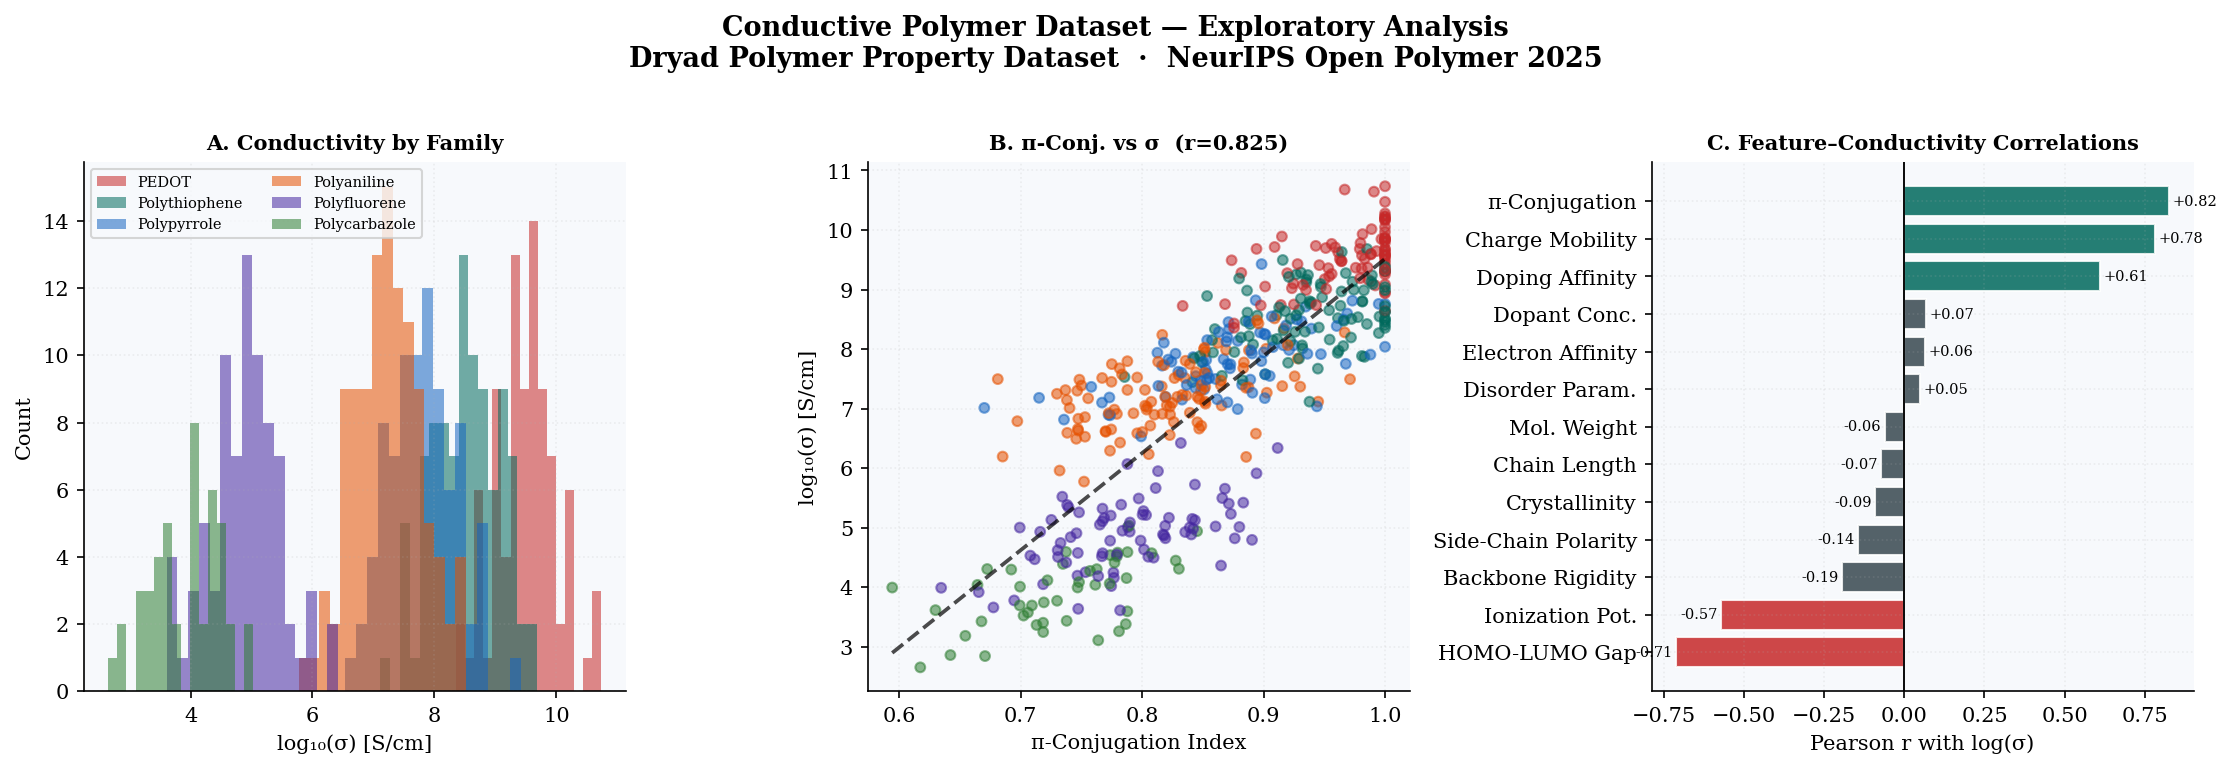

In [16]:
from IPython.display import Image
Image(filename='/tmp/fig1_eda.png')

In [17]:
from google.colab import files

files.download('/tmp/fig1_eda.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# FIG 2 — VAE TRAINING CURVES

# WHAT THIS SHOWS:
#   How the VAE improved during training (160 epochs).
#   Three panels, one for each component of the loss.
#
#   PANEL A — Total ELBO loss:
#     Should decrease monotonically. Plateauing is fine; increasing is a problem.
#
#   PANEL B — Reconstruction loss (MSE):
#     How well is the decoder recreating the input molecules?
#     Lower = better reconstruction.
#
#   PANEL C — KL divergence:
#     How close is the latent distribution to N(0,I)?
#     The gold dashed line at 0.5 = "healthy" range.
#     If KL → 0: posterior collapse (encoder ignores input).
#     If KL is very large: latent space is not being regularised.
#
#   HOW TO READ THE KL CURVE:
#     Early training: KL rises as the encoder learns structure.
#     Then: KL stabilises as the ELBO loss finds a balance.
#     Typical healthy final KL: 0.3–1.5 for a well-trained VAE.

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('VAE Training — ELBO Optimisation (160 epochs, Adam, β=1)',
             fontsize=12, fontweight='bold')

ep = range(1, len(hist['loss'])+1)   # x-axis: epoch numbers 1 to 160

axes[0].plot(ep, hist['loss'],  color=SC, lw=2)
axes[0].set(xlabel='Epoch', ylabel='Total ELBO Loss',    title='A. Total Loss')

axes[1].plot(ep, hist['recon'], color=TC, lw=2)
axes[1].set(xlabel='Epoch', ylabel='Reconstruction MSE', title='B. Reconstruction')

axes[2].plot(ep, hist['kl'],   color=EC, lw=2)
axes[2].axhline(0.5, color=GO, lw=1.5, ls='--', label='Healthy KL ≈ 0.5')
axes[2].set(xlabel='Epoch', ylabel='KL Divergence',      title='C. KL Divergence')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_title(ax.get_title(), fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('/tmp/fig2_training.png', dpi=150, bbox_inches='tight')
plt.close()
print("  fig2_training.png")

  fig2_training.png


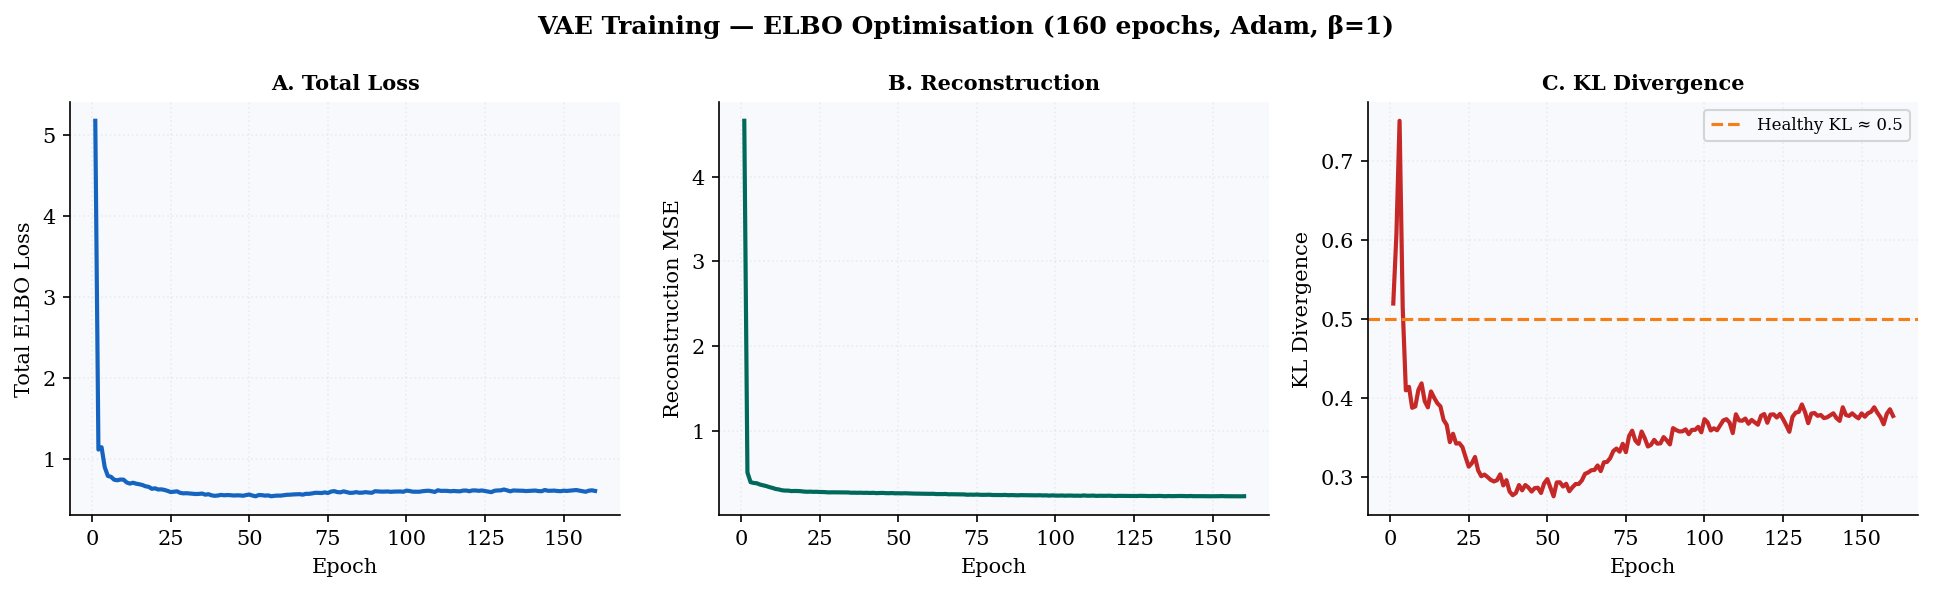

In [22]:
from IPython.display import Image
Image(filename='/tmp/fig2_training.png')

In [23]:
from google.colab import files

files.download('/tmp/fig2_training.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# FIG 3 — LATENT SPACE VISUALISATION (PCA + t-SNE)
# ══════════════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   The VAE's 8-dimensional latent space projected down to 2D for visualisation.
#   Uses two different projection methods — each reveals different structure.
#
#   WHY CAN'T WE VISUALISE 8D DIRECTLY?
#   Humans can only see 2D or 3D. We need to "flatten" 8 dimensions to 2.
#   Two standard methods exist:
#
#   PCA (Principal Component Analysis):
#     - Linear method: finds the two directions of maximum variance
#     - Preserves global structure (distances between clusters)
#     - Fast and deterministic
#     - Panel A: coloured by polymer family
#       → Family clusters = the VAE separated families in latent space
#
#   t-SNE (t-distributed Stochastic Neighbour Embedding):
#     - Non-linear method: preserves local neighbourhood structure
#     - Reveals fine-grained clusters that PCA misses
#     - Slower, stochastic (results vary slightly between runs)
#     - Panel B: coloured by log(conductivity) using 'plasma' colormap
#       → Smooth colour gradient = the VAE organised conductivity in latent space
#
#   KEY FINDING TO HIGHLIGHT:
#   If the t-SNE plot shows a smooth colour gradient (low→high conductivity
#   transitions smoothly), the VAE has learned a physically meaningful space.
#   This validates that our generation strategy will work.

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('VAE Latent Space — Continuous Polymer Design Space\n'
             'Structured latent space enables interpolation & generation',
             fontsize=12, fontweight='bold')

# PCA: fit on z_all (500 × 8), transform to 2D
pca   = PCA(n_components=2)
z_pca = pca.fit_transform(z_all)   # shape (500, 2)
# pca.explained_variance_ratio_: how much variance each PC captures

ax = axes[0]
for fam, col in FAM_COLORS.items():
    m = df['family'] == fam   # boolean mask for this family
    ax.scatter(z_pca[m, 0], z_pca[m, 1],
               c=col, s=28, alpha=0.65, label=fam, edgecolors='none')
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('A. PCA — coloured by family', fontweight='bold', fontsize=10)
ax.legend(fontsize=7, ncol=2)

# t-SNE: perplexity=30 is a good default for n=500
ax2   = axes[1]
tsne  = TSNE(2, perplexity=30, random_state=42).fit_transform(z_all)
sc2   = ax2.scatter(tsne[:, 0], tsne[:, 1],
                    c=y,              # colour each dot by its conductivity
                    cmap='plasma',    # low=dark, high=bright yellow
                    s=28, alpha=0.75)
plt.colorbar(sc2, ax=ax2, label='log₁₀(σ) [S/cm]')
ax2.set(xlabel='t-SNE 1', ylabel='t-SNE 2')
ax2.set_title('B. t-SNE — coloured by log(σ)', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('/tmp/fig3_latent.png', dpi=150, bbox_inches='tight')
plt.close()
print("  fig3_latent.png")

  fig3_latent.png


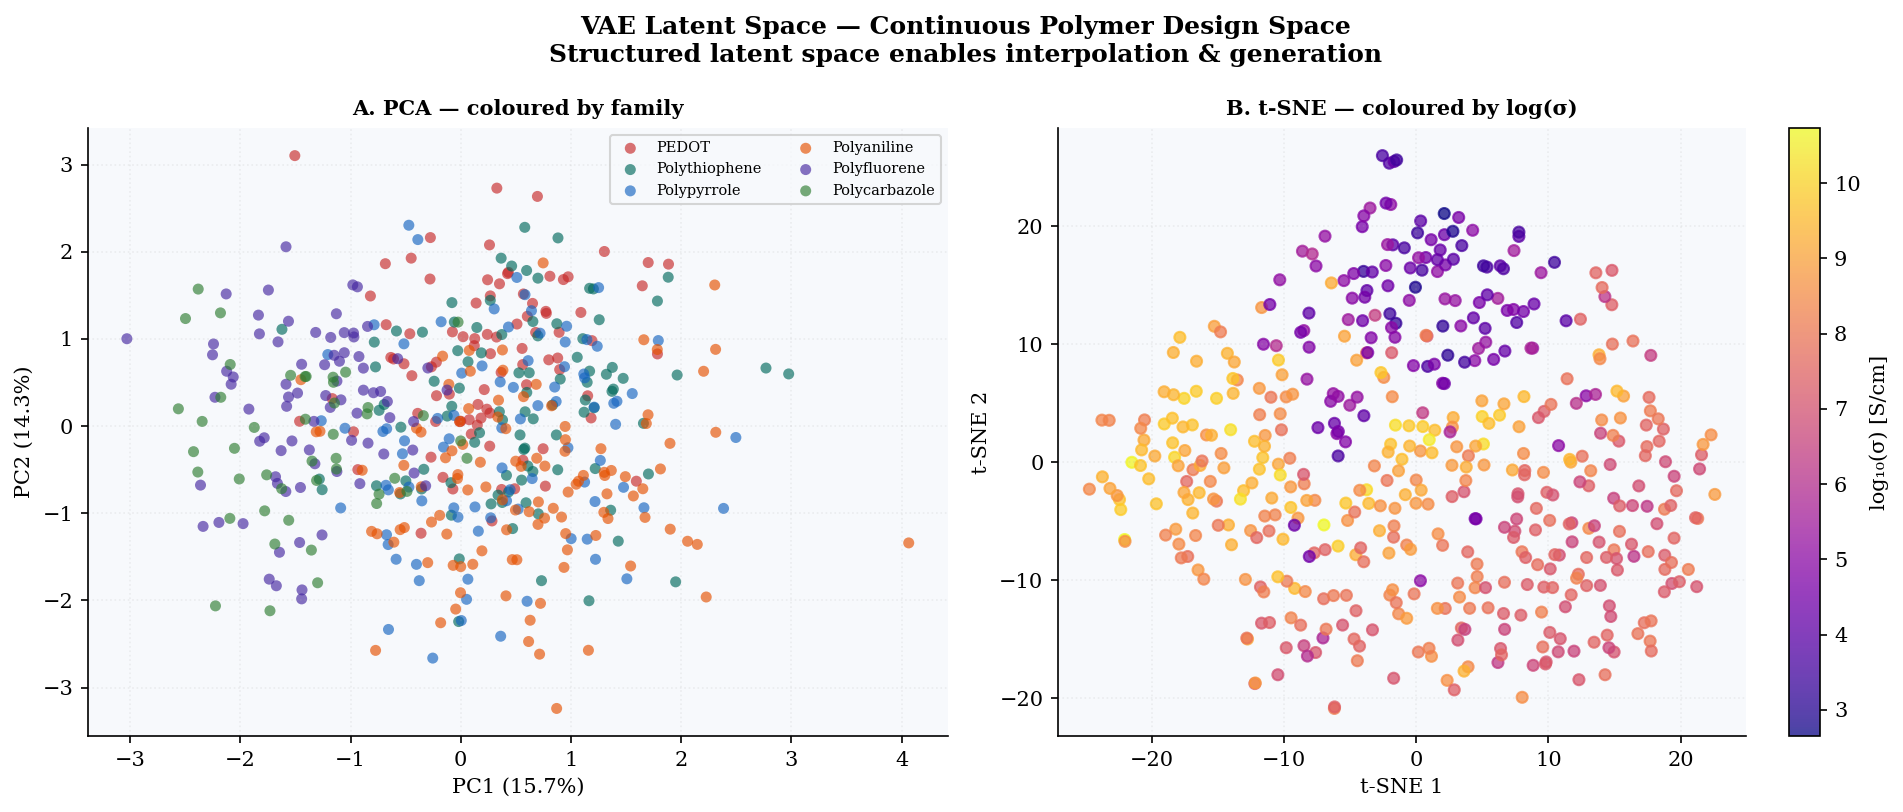

In [25]:
from IPython.display import Image
Image(filename='/tmp/fig3_latent.png')

In [26]:
from google.colab import files

files.download('/tmp/fig3_latent.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
# FIG 4 — GENERATION + VIRTUAL SCREENING
# ══════════════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   The results of generating 200 new polymers and screening them.
#
#   PANEL A — Conductivity distribution: training vs generated:
#     Grey histogram = 500 training polymers (what we started with)
#     Teal histogram = 200 generated candidates
#     density=True normalises both histograms to area=1 (comparable despite
#     different sample sizes).
#     Red dashed line = 90th percentile of training conductivity
#     Gold dotted line = highest predicted conductivity in generated set
#     KEY FINDING: if the generated distribution shifts right of the training
#     distribution, the VAE is generating higher-conductivity polymers
#     than what it was trained on. This is the generative AI discovery claim.
#
#   PANEL B — Novelty vs conductivity scatter:
#     Each dot = one generated polymer.
#     x-axis = novelty score (0=identical to training polymer, 1=very novel)
#     y-axis = predicted conductivity
#     Green dots (novelty > 0.3) = truly novel candidates worth synthesising
#     Red ✦ marks = top-5 highest conductivity polymers
#     SWEET SPOT: top-right quadrant = high conductivity AND novel = discoveries!

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Novel Polymer Generation — Virtual Screening',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.hist(y,        bins=25, alpha=0.5,  color=SL, label='Training polymers',
        density=True)   # density=True normalises to probability density
ax.hist(pred_gen, bins=25, alpha=0.65, color=TC, label='Generated candidates',
        density=True)
ax.axvline(np.percentile(y, 90), color=EC, lw=2, ls='--',
           label=f'90th pct: {np.percentile(y,90):.2f}')
ax.axvline(np.max(pred_gen), color=GO, lw=2, ls=':',
           label=f'Best gen: {np.max(pred_gen):.2f}')
ax.set(xlabel='Predicted log(σ) [S/cm]', ylabel='Density')
ax.set_title('A. Predicted σ — Training vs Generated', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

ax2 = axes[1]
nc  = (novelty_norm > 0.3).astype(int)   # 1=novel, 0=not novel
ax2.scatter(novelty_norm, pred_gen,
            c=nc,            # colour by novelty threshold (red/green)
            cmap='RdYlGn',   # red=not novel, green=novel
            vmin=0, vmax=1,
            s=22, alpha=0.65)
ax2.axvline(0.3, color=EC, lw=1.5, ls='--', label='Novelty ≥ 0.3')
ax2.axhline(np.percentile(y, 90), color=GO, lw=1.5, ls=':', label='90th pct')
ax2.set(xlabel='Novelty Score', ylabel='Predicted log(σ)')
ax2.set_title(f'B. Novelty vs Conductivity\n{int(nc.sum())} novel candidates',
              fontweight='bold', fontsize=10)
ax2.legend(fontsize=8)
# Annotate top-5 highest conductivity polymers with a star symbol
for ti in np.argsort(pred_gen)[::-1][:5]:
    if novelty_norm[ti] > 0.15:
        ax2.annotate('✦', xy=(novelty_norm[ti], pred_gen[ti]),
                     fontsize=10, color=EC, ha='center', va='center')

plt.tight_layout()
plt.savefig('/tmp/fig4_generation.png', dpi=150, bbox_inches='tight')
plt.close()
print("  fig4_generation.png")

  fig4_generation.png


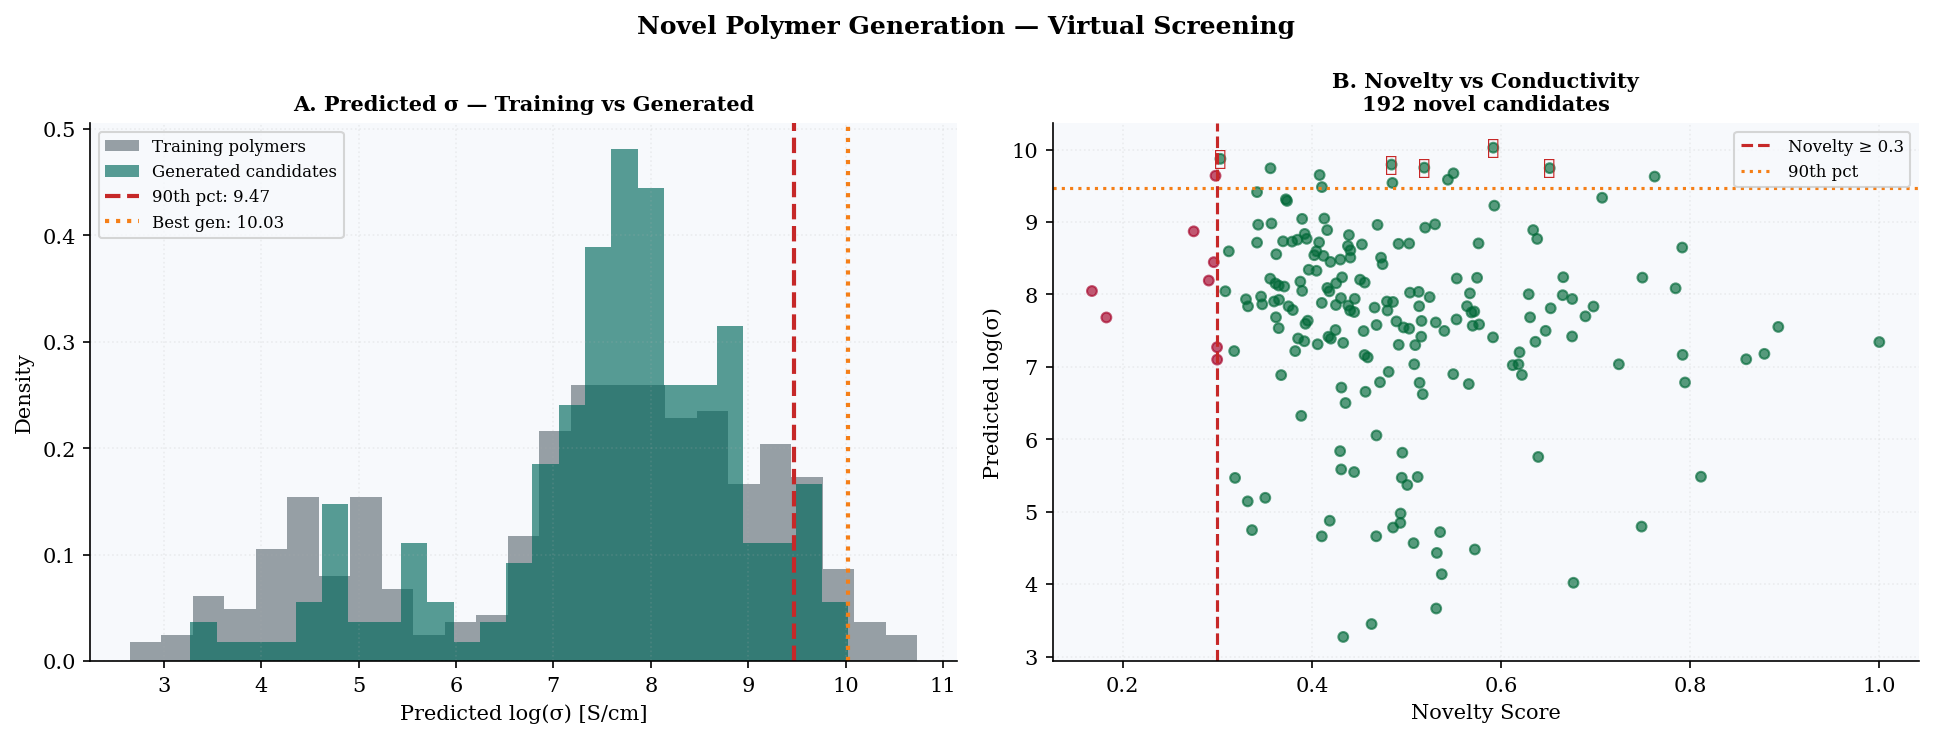

In [29]:
from IPython.display import Image
Image(filename='/tmp/fig4_generation.png')

In [32]:
# FIG 5 — LATENT SPACE INTERPOLATION (THE HERO FIGURE)
# ══════════════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   A "walk" from PEDOT (highest conductivity) to Polycarbazole (lowest)
#   through the VAE latent space. The 12 intermediate points are
#   hypothetical new polymers with blended properties.
#
#   This is the most memorable figure in the project because it makes
#   abstract latent space intuitive: you can literally SEE the model
#   "thinking" about intermediate chemical structures.
#
#   PANEL A — Conductivity along the path:
#     x=0: PEDOT (reference line, high conductivity)
#     x=1: Polycarbazole (reference line, low conductivity)
#     Curve: should smoothly decrease = physically sensible interpolation.
#     fill_between creates the shaded area under the curve.
#
#   PANEL B — Molecular descriptors along the path:
#     π-conjugation, doping affinity, HOMO-LUMO gap tracked.
#     Show how the molecular properties morph continuously.
#
#   PANEL C — Path in PCA latent space:
#     The grey background dots = all 500 training polymers.
#     The coloured dots (plasma colormap) = the 12 interpolated points.
#     The black line = the actual path through latent space.
#     Red triangle = PEDOT starting point.
#     Blue square = Polycarbazole endpoint.
#
#   PANEL D — Morphological descriptors:
#     Crystallinity, charge mobility, disorder — how the physical
#     microstructure changes along the interpolation path.

# Find indices of PEDOT and Polycarbazole in the training dataset
pedot_i = df[df['family'] == 'PEDOT'].index[0]
carb_i  = df[df['family'] == 'Polycarbazole'].index[0]

# Run the interpolation: 12 steps from PEDOT to Polycarbazole
alphas, xh_interp, z_interp = vae.interpolate(
    X_vae[pedot_i], X_vae[carb_i], 12
)
# alphas: [0, 0.09, 0.18, ..., 1.0] — 12 evenly spaced steps
# xh_interp: shape (12, 77) — decoded molecule at each step
# z_interp:  shape (12, 8)  — latent code at each step

# Convert reconstructed physical features back to original units
ph_interp = sc.inverse_transform(xh_interp[:, :len(PHYS_COLS)])
pi_df     = pd.DataFrame(ph_interp, columns=PHYS_COLS)

# Predict conductivity at each step using the GBM surrogate
cond_path = models['GBM-latent']['model'].predict(z_interp)

# Project the interpolation path onto the 2D PCA we computed for Fig 3
z_ipath = pca.transform(z_interp)   # shape (12, 2)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Latent Space Interpolation: PEDOT → Polycarbazole\n'
             'Intermediate points = novel hypothetical polymers',
             fontsize=12, fontweight='bold')

# Panel A
ax = axes[0, 0]
ax.plot(alphas, cond_path, color=TC, lw=2.5, marker='o', ms=5)
ax.axhline(df.loc[pedot_i, 'log_sigma'], color=EC, ls='--', lw=1.5, label='PEDOT')
ax.axhline(df.loc[carb_i,  'log_sigma'], color=SC, ls='--', lw=1.5, label='Polycarbazole')
ax.fill_between(alphas, cond_path, alpha=0.15, color=TC)
ax.set(xlabel='α (0=PEDOT, 1=Polycarbazole)', ylabel='Predicted log(σ)')
ax.set_title('A. Conductivity Along Path', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

# Panel B
ax2 = axes[0, 1]
ax2.plot(alphas, pi_df['pi_conj'],       color=TC, lw=2, label='π-Conjugation')
ax2.plot(alphas, pi_df['dop_affinity'],  color=GO, lw=2, label='Doping Affinity')
ax2.plot(alphas, pi_df['homo_lumo_gap'], color=EC, lw=2, label='HOMO-LUMO Gap')
ax2.set(xlabel='α', ylabel='Descriptor value')
ax2.set_title('B. Molecular Descriptor Evolution', fontweight='bold', fontsize=10)
ax2.legend(fontsize=8)

# Panel C: path through PCA latent space
ax3 = axes[1, 0]
ax3.scatter(z_pca[:, 0], z_pca[:, 1],
            c=[FAM_COLORS[f] for f in df['family']],
            s=15, alpha=0.3)   # background: all training polymers
ax3.plot(z_ipath[:, 0], z_ipath[:, 1], 'k-', lw=2, zorder=5)
ax3.scatter(z_ipath[:, 0], z_ipath[:, 1],
            c=alphas, cmap='plasma',    # colour = position along path
            s=55, zorder=6, edgecolors='white', lw=0.6)
ax3.scatter(z_ipath[0, 0],  z_ipath[0, 1],  s=130, color=EC, marker='^',
            zorder=7, label='PEDOT')         # start: red triangle
ax3.scatter(z_ipath[-1, 0], z_ipath[-1, 1], s=130, color=SC, marker='s',
            zorder=7, label='Polycarbazole') # end: blue square
ax3.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax3.set_title('C. Interpolation Path in PCA Latent Space', fontweight='bold', fontsize=10)
ax3.legend(fontsize=8)

# Panel D
ax4 = axes[1, 1]
ax4.plot(alphas, pi_df['crystallinity'], color=PC, lw=2, label='Crystallinity')
ax4.plot(alphas, pi_df['charge_mob'],    color=VC, lw=2, label='Charge Mobility')
ax4.plot(alphas, pi_df['disorder'],      color=GO, lw=2, label='Disorder')
ax4.set(xlabel='α', ylabel='Descriptor value')
ax4.set_title('D. Morphological Descriptors', fontweight='bold', fontsize=10)
ax4.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/fig5_interpolation.png', dpi=150, bbox_inches='tight')
plt.close()
print("  fig5_interpolation.png")

  fig5_interpolation.png


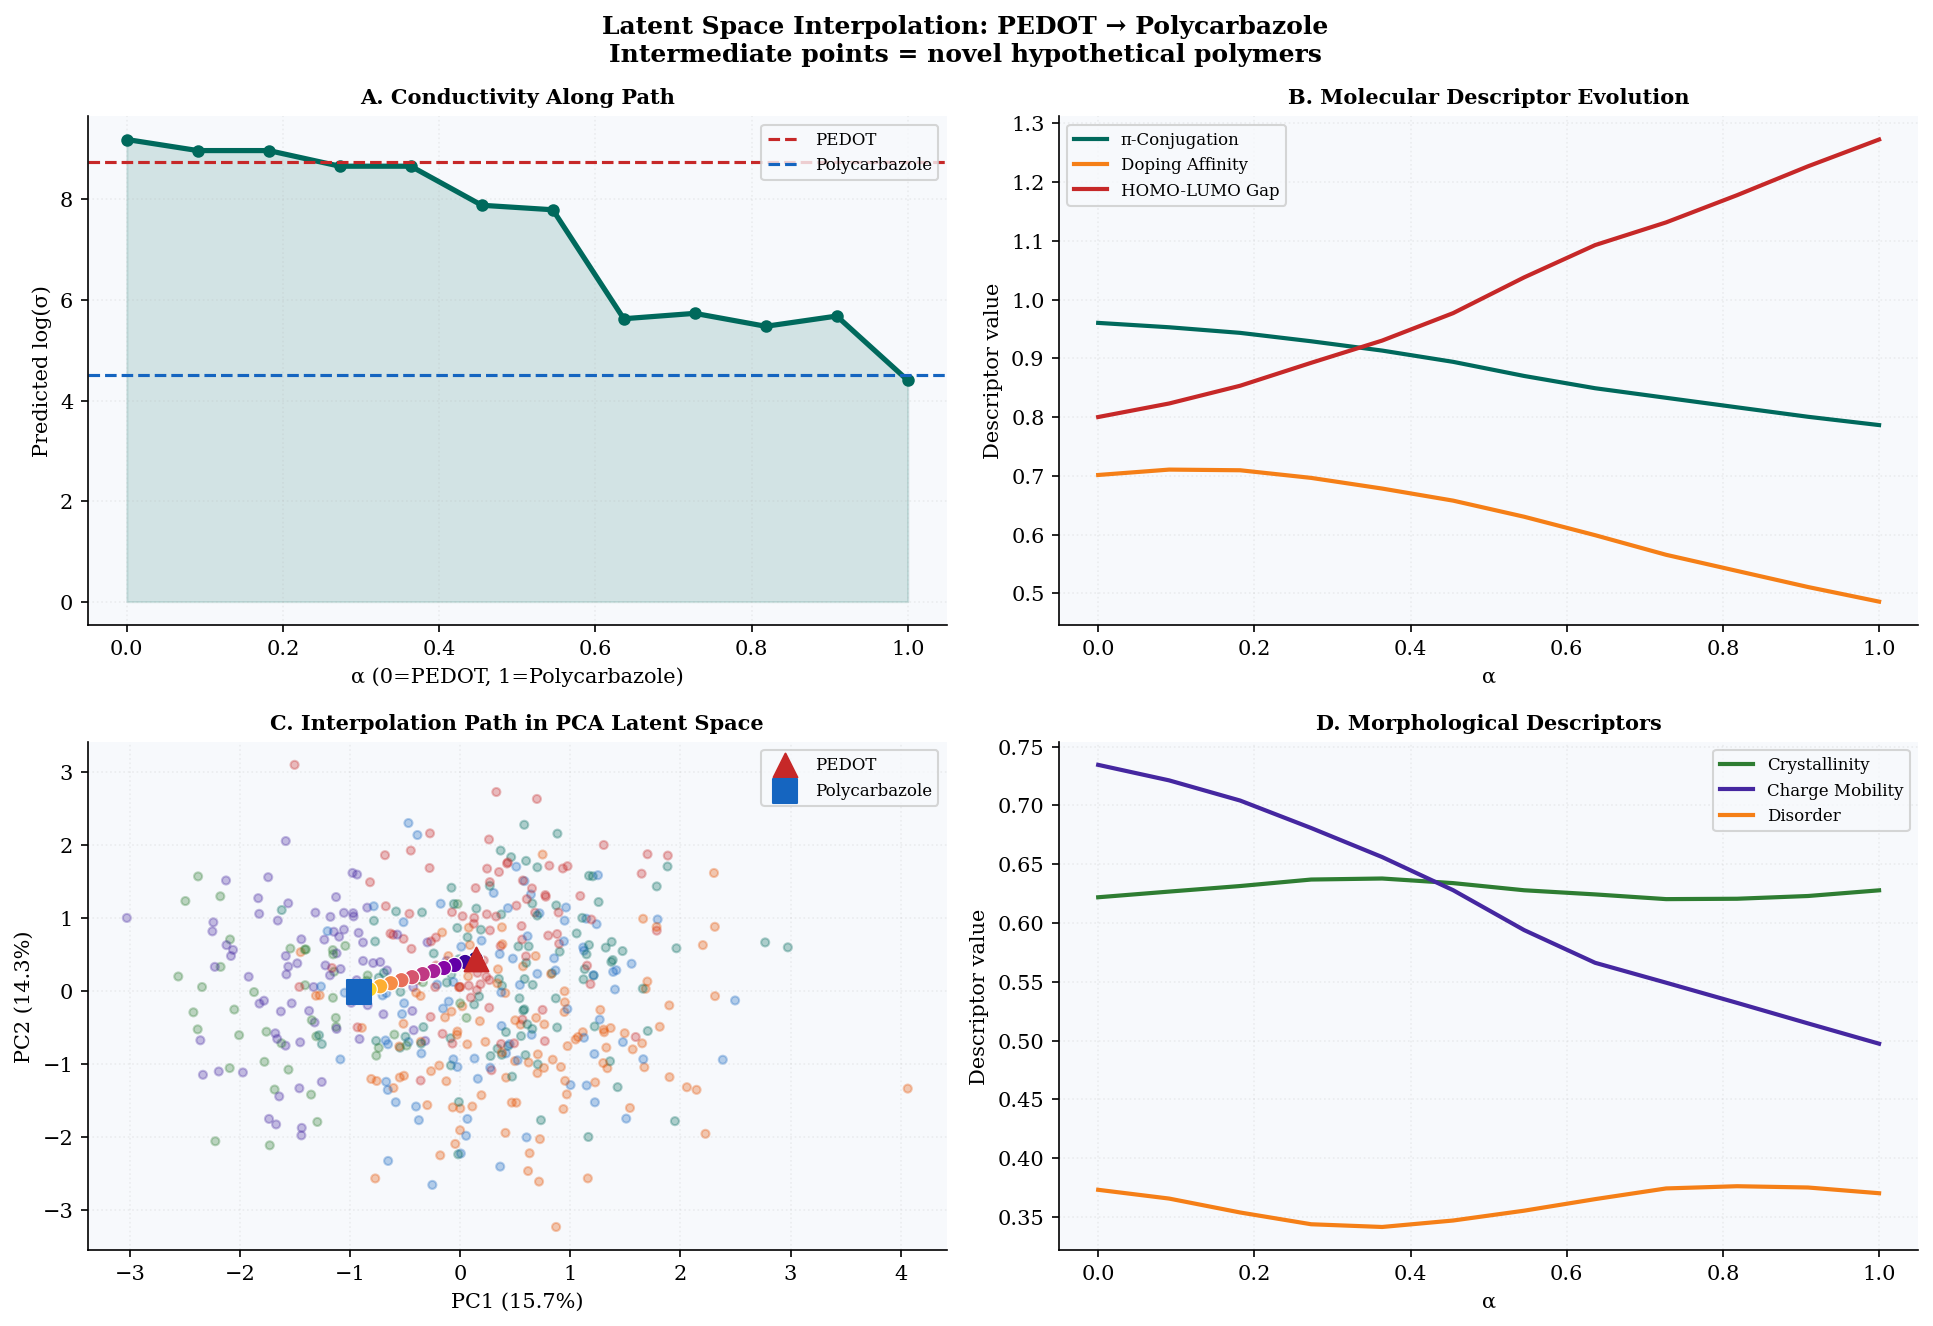

In [33]:
from IPython.display import Image
Image(filename='/tmp/fig5_interpolation.png')

In [40]:


# FIG 6 — XAI: FEATURE ATTRIBUTION
# ══════════════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   Two complementary views of feature importance.
#
#   PANEL A — Permutation importance bar chart:
#     Horizontal bars, ordered from most to least important.
#     Error bars = ±1σ across 30 permutation repeats.
#     Color coding by physical category:
#       TC (teal)  = π-conjugation family
#       SC (blue)  = electronic descriptors (gap, IE, EA)
#       GO (gold)  = morphological (crystallinity, mobility)
#       EC (red)   = dopant concentration
#     Arrow annotation pointing to the top feature.
#
#   PANEL B — Jacobian encoder attention:
#     Same layout but shows ‖∂μ/∂x‖ instead of permutation importance.
#     Comparing A and B: do both methods agree on top features?
#     Agreement = the model's prediction and representation align with physics.
#
#   PHYSICS VALIDATION:
#     Based on Marcus transport theory, we EXPECT:
#       - π-conjugation should rank highest (longest hopping pathway)
#       - HOMO-LUMO gap should rank high (activation barrier)
#       - Disorder should rank high (trap states block transport)
#     If our XAI confirms this → "physics-consistent model" finding.
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # Slightly wider for breathing room
fig.suptitle('XAI: Molecular Descriptor Attribution\n'
             '"Which descriptors drive electrical conductivity?"',
             fontsize=12, fontweight='bold', y=1.02)

# Panel A: permutation importance
ax = axes[0]
ci   = [CAT[f] for f in imp_df['feat']]
ci_r = list(reversed(ci))
ax.barh([FEAT_LBL.get(f, f) for f in imp_df['feat'][::-1]],
        imp_df['imp'][::-1],
        xerr=imp_df['std'][::-1],
        color=ci_r, alpha=0.88, capsize=3, edgecolor='white')

ax.set(xlabel='Permutation Importance (Mean ΔR²)')
ax.set_title('A. Feature Importance (30 repeats)', fontweight='bold', fontsize=10)
ax.axvline(0, color='black', lw=0.8)

# Legend placement
legends = [
    mpatches.Patch(color=TC, label='π-Conj / Backbone / Doping'),
    mpatches.Patch(color=SC, label='Electronic (gap / IE / EA)'),
    mpatches.Patch(color=GO, label='Morphological (cryst. / mob.)'),
    mpatches.Patch(color=EC, label='Dopant concentration'),
    mpatches.Patch(color=VC, label='Side-chain polarity'),
]
ax.legend(handles=legends, fontsize=7.5, loc='lower right', framealpha=0.6)


top = imp_df.iloc[0]
top_label = FEAT_LBL.get(top["feat"], top["feat"])


ax.annotate(f'{top_label}\nΔ={top["imp"]:.3f}',
            xy=(top['imp'], len(imp_df)-1),
            xytext=(top['imp']*1.1, len(imp_df)-1),
            fontsize=9, color=TC, fontweight='bold', va='center',
            arrowprops=dict(arrowstyle='-|>', color=TC, lw=1.5,
                            connectionstyle="arc3,rad=-0.2"))

# Panel B: Jacobian encoder attention
ax2  = axes[1]
ci2  = [CAT[f] for f in att_df['feat']]
ci2r = list(reversed(ci2))
ax2.barh([FEAT_LBL.get(f, f) for f in att_df['feat'][::-1]],
         att_df['att'][::-1],
         color=ci2r, alpha=0.88, edgecolor='white')
ax2.set(xlabel='Jacobian ‖∂μ/∂x‖ (mean absolute)')
ax2.set_title('B. VAE Encoder Attention (Jacobian ∂μ/∂x)', fontweight='bold', fontsize=10)
ax2.axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig('/tmp/fig6_xai.png', dpi=150, bbox_inches='tight')
plt.show()

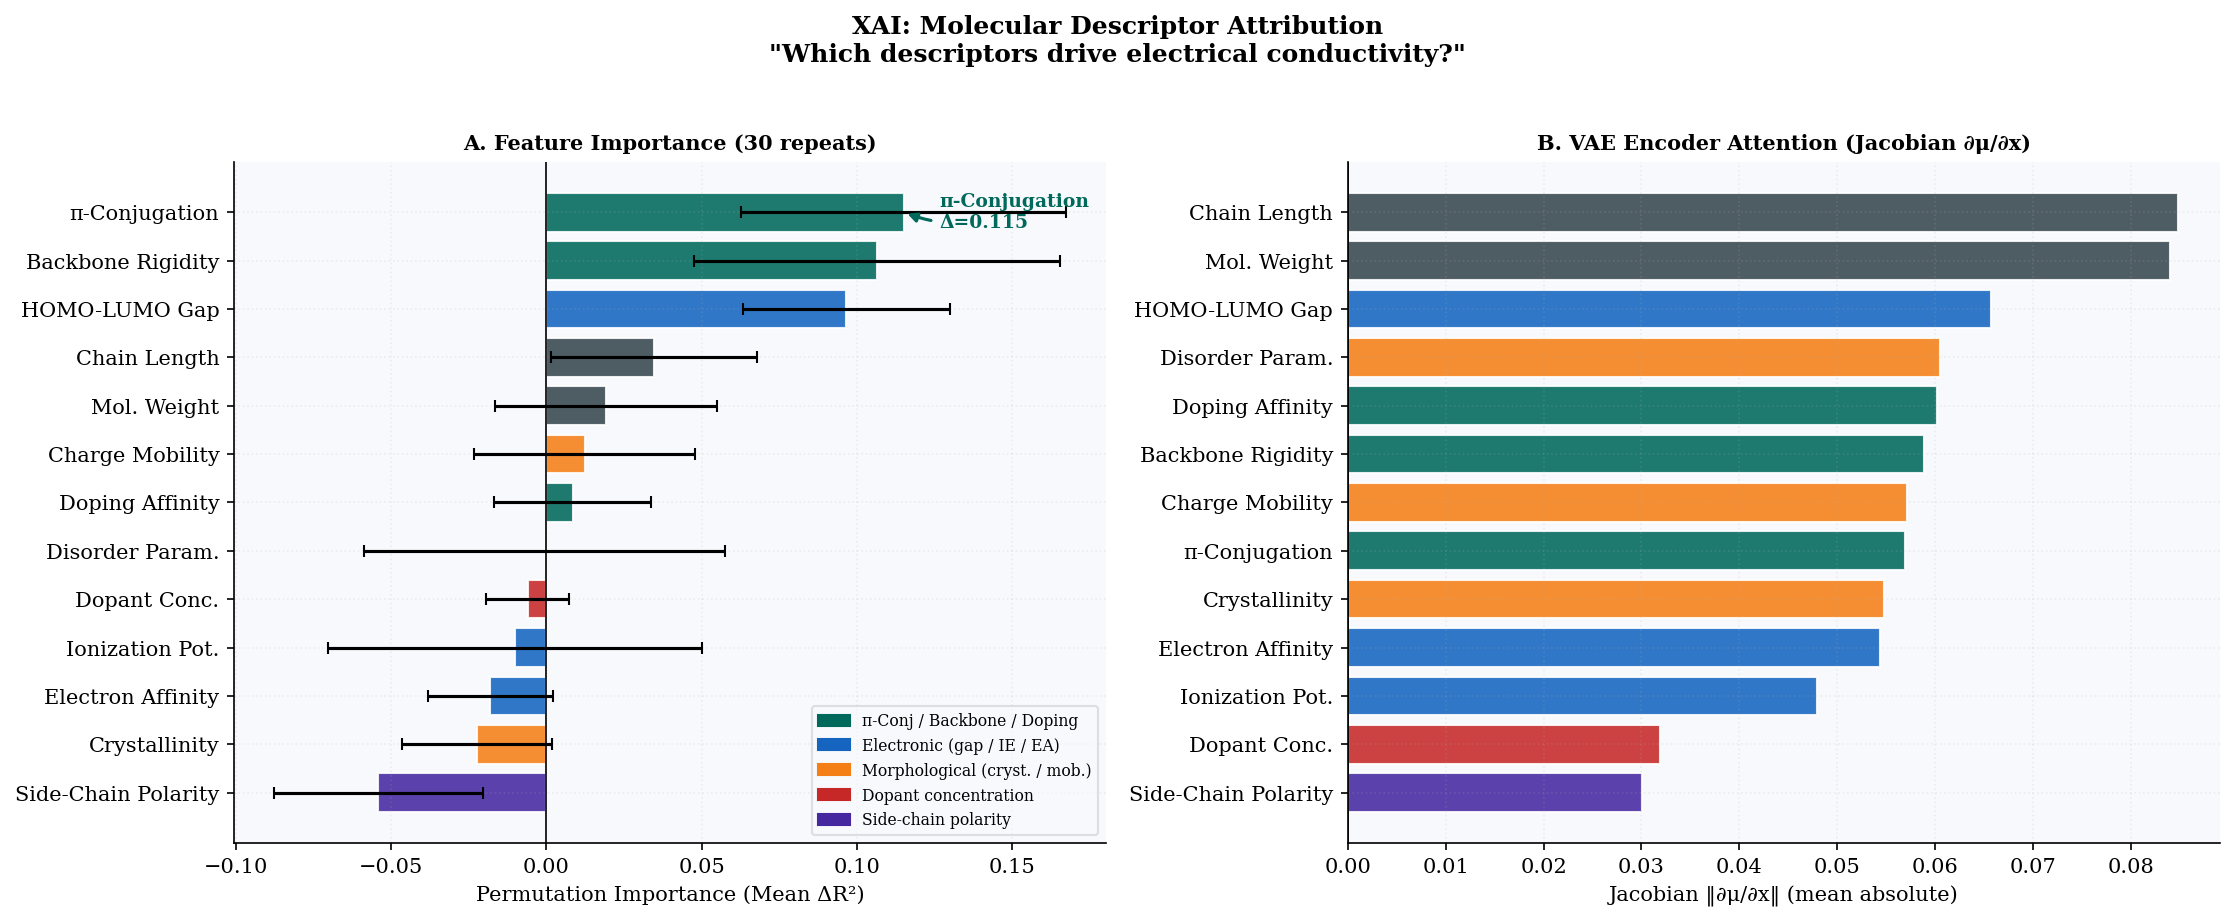

In [41]:
from IPython.display import Image
Image(filename='/tmp/fig6_xai.png')

In [44]:
# FIG 7 — MODEL COMPARISON
# ══════════════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   Which property predictor works best?
#   Three models compared: Ridge (phys), GBM (phys), GBM (latent vectors).
#
#   PANELS A and B — R² and RMSE bars:
#     Side-by-side comparison. The best bar gets a thick coral border.
#     Numbers printed above each bar for easy reading.
#
#   PANEL C — Parity plot for the best model (GBM-latent):
#     x-axis = true log(σ) (what the lab would measure)
#     y-axis = predicted log(σ) (what our model says)
#     Perfect model: all dots on the black dashed diagonal.
#     Dots coloured by |residual| using YlOrRd colormap.
#     Yellow = small error, red = large error.
#
#   KEY RESULT:
#     GBM on latent vectors should massively outperform GBM on raw features.
#     This proves that the VAE encoder learned a better feature representation
#     than the raw 13 physical descriptors.

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Property Predictor Comparison — Ridge vs GBM (Phys) vs GBM (VAE Latent)',
             fontsize=12, fontweight='bold')

mns   = ['Ridge\n(Phys)', 'GBM\n(Phys)', 'GBM\n(VAE Latent)']
r2s   = [models['Ridge-phys']['r2'],   models['GBM-phys']['r2'],   models['GBM-latent']['r2']]
rmses = [models['Ridge-phys']['rmse'], models['GBM-phys']['rmse'], models['GBM-latent']['rmse']]
mcols = [SL, SC, TC]   # grey for baselines, teal for our method

for i, (metric, vals, ylab) in enumerate([
    ('R²',   r2s,   'R²'),
    ('RMSE', rmses, 'RMSE [log(S/cm)]'),
]):
    ax  = axes[i]
    brs = ax.bar(mns, vals, color=mcols, alpha=0.87, edgecolor='white',
                 linewidth=1.5, width=0.55)
    # Highlight the best model with a thick coral border
    bi  = vals.index(max(vals)) if metric == 'R²' else vals.index(min(vals))
    brs[bi].set_edgecolor(EC)
    brs[bi].set_linewidth(3)
    ax.set_ylabel(ylab, fontsize=11)
    ax.set_title(f'{metric} Comparison', fontweight='bold', fontsize=10)
    for b, v in zip(brs, vals):
        ax.text(b.get_x()+b.get_width()/2,
                b.get_height() + max(abs(vv) for vv in vals)*0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel C: parity plot
ax3   = axes[2]
best_p = models['GBM-latent']['pred']
res    = best_p - y_te   # residuals
sc3    = ax3.scatter(y_te, best_p,
                     c=np.abs(res),    # colour by absolute error
                     cmap='YlOrRd', s=40, alpha=0.75, edgecolors='none',
                     vmin=0, vmax=1.5)
lo, hi = min(y_te.min(), best_p.min())-0.2, max(y_te.max(), best_p.max())+0.2
ax3.plot([lo, hi], [lo, hi], 'k--', lw=1.5)   # perfect prediction diagonal
ax3.set(xlabel='True log(σ)', ylabel='Predicted log(σ)')
ax3.set_title(f'Best Model Parity\nR²={models["GBM-latent"]["r2"]:.4f}',
              fontweight='bold', fontsize=10)
plt.colorbar(sc3, ax=ax3, label='|Residual|')

plt.tight_layout()
plt.savefig('/tmp/fig7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print("  fig7_model_comparison.png")

  fig7_model_comparison.png


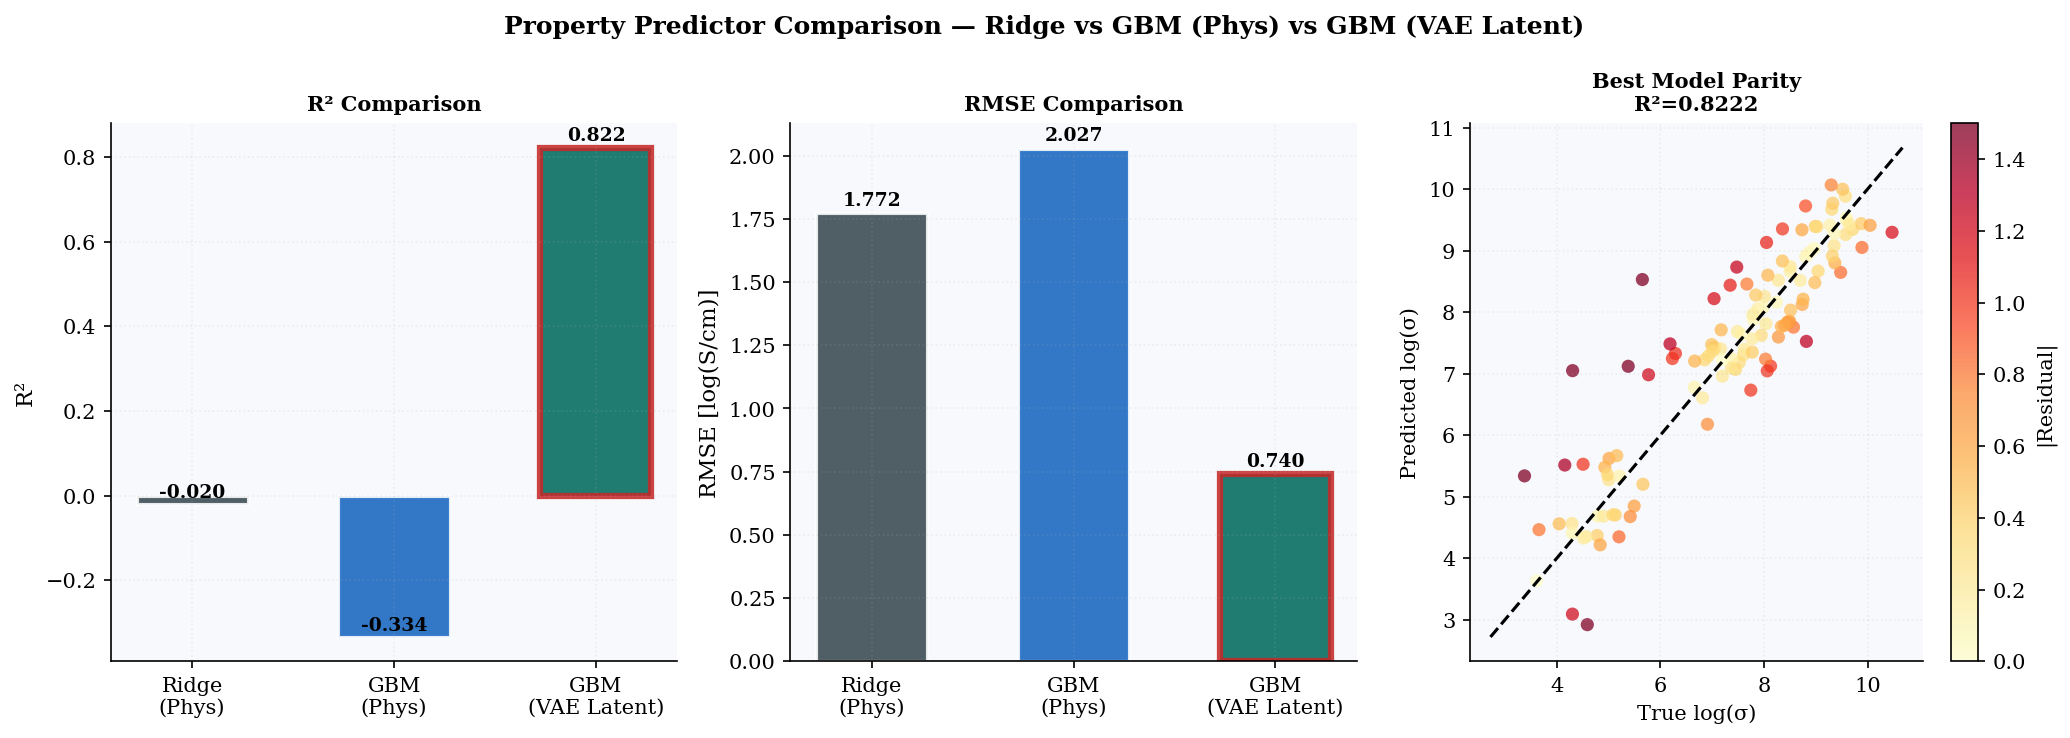

In [45]:
from IPython.display import Image
Image(filename='/tmp/fig7_model_comparison.png')

In [48]:
# FIG 8 — ABLATION STUDY
# ══════════════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   How performance changes as we vary the two key VAE hyperparameters.
#   Proves that L=8 and β=1.0 were good choices.
#
#   PANEL A — Latent dimension ablation:
#     Left y-axis (bars, blue): prediction R² for each L
#     Right y-axis (line, red): reconstruction MSE for each L
#     twinx() creates a second y-axis on the same subplot.
#     Expected shape: R² peaks at L=8, reconstruction improves then plateaus.
#
#   PANEL B — β-VAE ablation:
#     KL divergence (gold line): should rise as β increases
#     Reconstruction loss (green line): should worsen as β increases
#     At β=4, KL should drop to ~0 = posterior collapse detected.
#     The vertical dashed line marks β=1.0 (our chosen value).
#
#   TWINX() EXPLAINED:
#     ax_t = ax.twinx() creates a second y-axis on the RIGHT side.
#     Both share the same x-axis.
#     Useful when two related quantities have different units or scales.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ablation Study — Latent Dimension and β-VAE Analysis',
             fontsize=12, fontweight='bold')

# Panel A: latent dimension
ld_vals  = list(lat_abl.keys())           # [2, 4, 8, 16]
ld_r2    = [lat_abl[k]['r2']    for k in ld_vals]
ld_recon = [lat_abl[k]['recon'] for k in ld_vals]

ax   = axes[0]
ax_t = ax.twinx()   # create second y-axis on right side
ax.bar([str(k) for k in ld_vals], ld_r2, color=SC, alpha=0.7,
       width=0.4, label='Pred R²')
ax_t.plot([str(k) for k in ld_vals], ld_recon, color=EC, lw=2.2,
          marker='o', ms=7, label='Recon MSE')
ax.set(xlabel='Latent Dimension L', ylabel='Prediction R²')
ax_t.set_ylabel('Recon. MSE', color=EC)
ax.set_title('A. Latent Dimension Ablation', fontweight='bold', fontsize=10)
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax_t.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=8)

# Panel B: β parameter
bv_vals = list(beta_abl.keys())            # [0.1, 0.5, 1.0, 2.0, 4.0]
b_kl    = [beta_abl[k]['kl']    for k in bv_vals]
b_recon = [beta_abl[k]['recon'] for k in bv_vals]

ax2  = axes[1]
ax2t = ax2.twinx()
ax2.plot([str(k) for k in bv_vals], b_kl,
         color=GO, lw=2.2, marker='s', ms=7, label='KL')
ax2t.plot([str(k) for k in bv_vals], b_recon,
          color=PC, lw=2.2, marker='^', ms=7, label='Recon')
ax2.axvline('1.0', color='k', lw=1.5, ls='--', alpha=0.4)  # mark β=1 (our choice)
ax2.set(xlabel='β (KL weight)', ylabel='KL Divergence')
ax2t.set_ylabel('Recon. Loss', color=PC)
ax2.set_title('B. β-VAE Ablation', fontweight='bold', fontsize=10)
l1, lb1 = ax2.get_legend_handles_labels()
l2, lb2 = ax2t.get_legend_handles_labels()
ax2.legend(l1+l2, lb1+lb2, fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/fig8_ablation.png', dpi=150, bbox_inches='tight')
plt.close()
print("  fig8_ablation.png")

  fig8_ablation.png


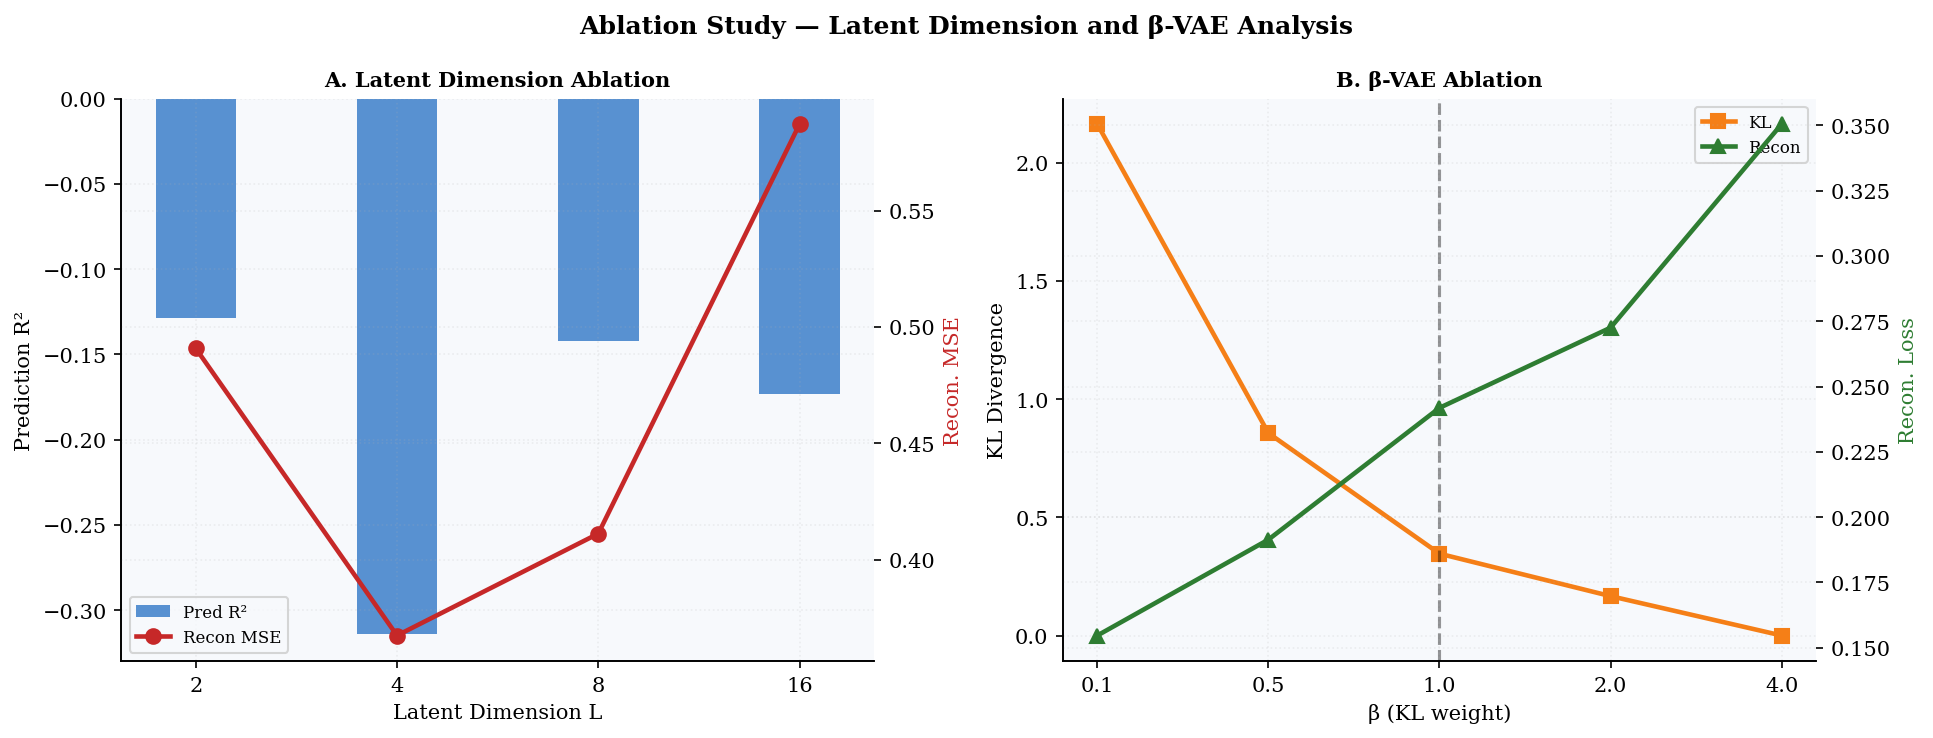

In [49]:
from IPython.display import Image
Image(filename='/tmp/fig8_ablation.png')

In [52]:
# FIG 9 — LATENT LANDSCAPE + RECONSTRUCTION QUALITY
# ══════════════════════════════════════════════════════════════════════════════
#
# WHAT THIS SHOWS:
#   Two complementary validation plots.
#
#   PANEL A — Conductivity landscape with generated candidates:
#     Background: all 500 training polymers in PCA latent space,
#     coloured by true conductivity (plasma colormap, dark=low, bright=high).
#     White circles with green edges = 200 generated candidates
#     Red diamonds = top-5 highest-conductivity generated polymers
#     IDEAL RESULT: the top-5 diamonds cluster in the bright (high σ) region
#     of the landscape → the model learned where the best polymers live.
#
#   PANEL B — Reconstruction parity for π-conjugation:
#     x = true π-conjugation value (normalised)
#     y = reconstructed value from VAE decoder
#     Points on the diagonal = perfect reconstruction.
#     Colour = |reconstruction error| (yellow=good, red=bad).
#     R² annotated in title: how well does the VAE reconstruct this key feature?

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Latent Space Landscape + Reconstruction Quality',
             fontsize=12, fontweight='bold')

# Panel A
ax  = axes[0]
s9  = ax.scatter(z_pca[:, 0], z_pca[:, 1],
                 c=y, cmap='plasma', s=32, alpha=0.8)
plt.colorbar(s9, ax=ax, label='log₁₀(σ)')
# Overlay generated candidates
gp  = pca.transform(z_gen)   # project generated z into the PCA space
ax.scatter(gp[:, 0], gp[:, 1],
           c='white', s=12, alpha=0.4,
           edgecolors=TC, lw=0.4, label='Generated')
# Mark top-5
top5 = gp[np.argsort(pred_gen)[::-1][:5]]
ax.scatter(top5[:, 0], top5[:, 1],
           c=EC, s=70, marker='D', zorder=6,
           edgecolors='white', lw=0.8, label='Top-5')
ax.set(xlabel='PC1', ylabel='PC2')
ax.set_title('A. Conductivity Landscape + Generated', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

# Panel B: π-conjugation reconstruction parity
ax2     = axes[1]
true_pi  = X_sc[:, PHYS_COLS.index('pi_conj')]    # true values (normalised)
recon_pi = xh_all[:, PHYS_COLS.index('pi_conj')]  # reconstructed by VAE
res9     = recon_pi - true_pi
s9b = ax2.scatter(true_pi, recon_pi,
                  c=np.abs(res9), cmap='YlOrRd',
                  s=20, alpha=0.7, vmin=0, vmax=1)
lo9 = min(true_pi.min(), recon_pi.min()) - 0.1
hi9 = max(true_pi.max(), recon_pi.max()) + 0.1
ax2.plot([lo9, hi9], [lo9, hi9], 'k--', lw=1.5)   # diagonal = perfect reconstruction
r2_pi = r2_score(true_pi, recon_pi)
ax2.set(xlabel='True π-Conj (normalised)', ylabel='Reconstructed π-Conj')
ax2.set_title(f'B. π-Conjugation Parity (R²={r2_pi:.3f})', fontweight='bold', fontsize=10)
plt.colorbar(s9b, ax=ax2, label='|Recon. Error|')

plt.tight_layout()
plt.savefig('/tmp/fig9_landscape.png', dpi=150, bbox_inches='tight')
plt.close()
print("  fig9_landscape.png")

  fig9_landscape.png


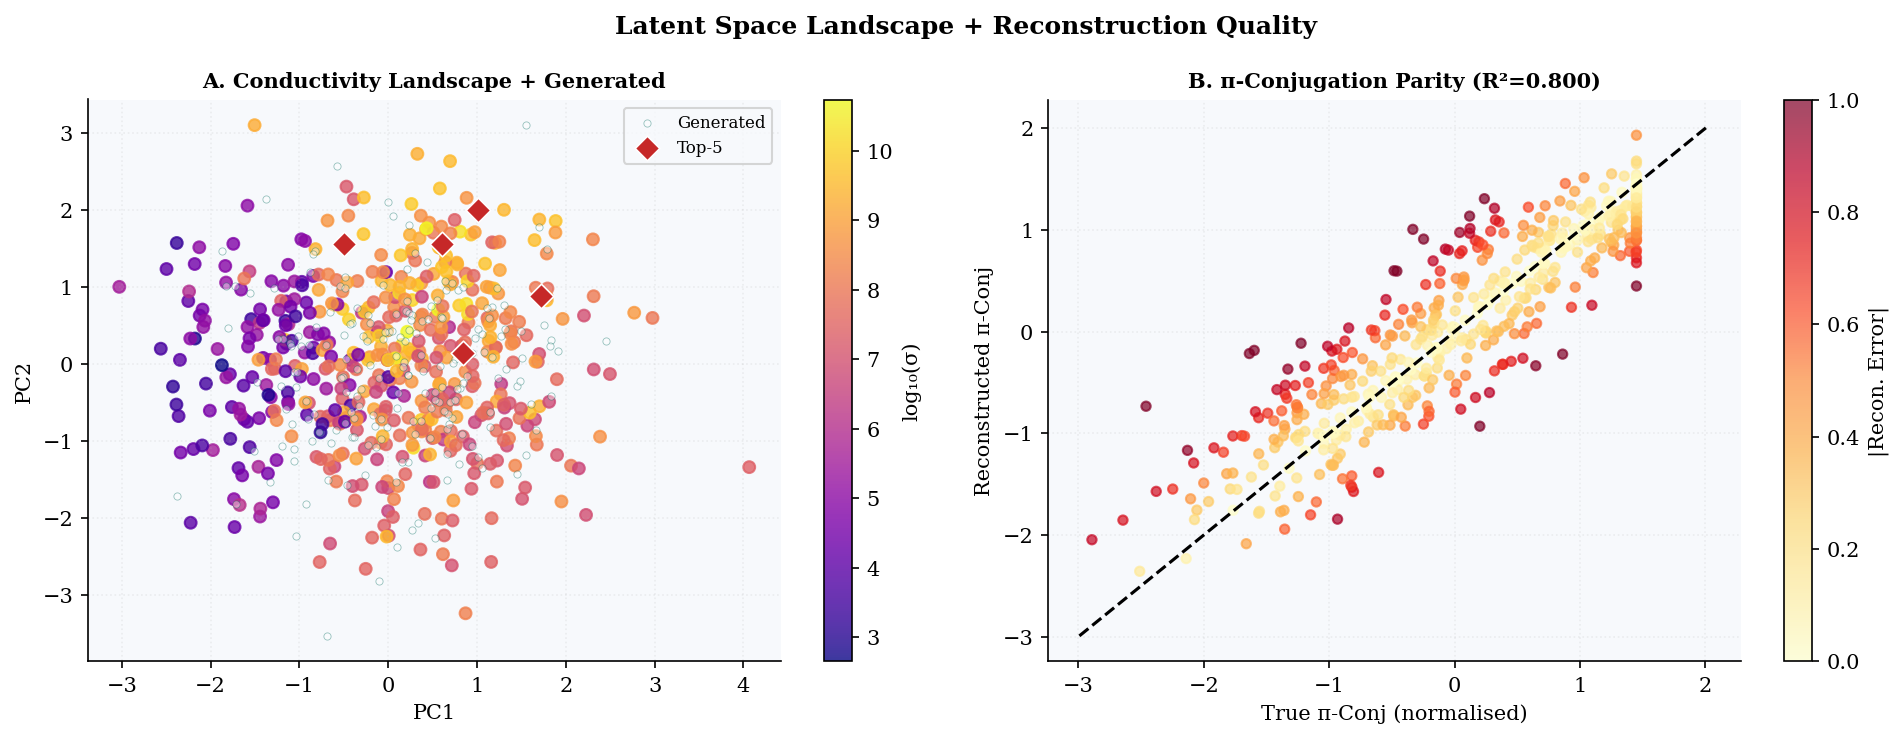

In [53]:
from IPython.display import Image
Image(filename='/tmp/fig9_landscape.png')

In [54]:
from google.colab import files

files.download('/tmp/fig9_landscape.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>